# Higgs Boson Machine Learning Kaggle Challenge

**Student:** Zane Coons  
**Course:** DATA-3402  
**Date Due:** May 1st, 2026

---

### Project Link
https://www.kaggle.com/competitions/higgs-boson/data  
Dataset permanently hosted at: https://opendata.cern.ch/record/328

### Challenge Description

The **Higgs Boson ML Challenge** was organized in 2014 by an interdisciplinary team of physicists and data scientists from CERN's ATLAS experiment, LAL (Université Paris-Sud), and ChaLearn, and was hosted on Kaggle from **May 12 to September 15, 2014**. It became one of the most popular Kaggle competitions ever run, attracting 1,785 teams and 1,942 participants with over 35,000 submissions.

#### Physics Background

The **Higgs boson** was the final missing piece of the Standard Model of particle physics - the theoretical framework that describes all known subatomic particles & forces. It was predicted theoretically nearly 50 years before its discovery (**Peter Higgs** predicted the existence of the Higgs boson in 1964), sering as the mechanism by which other elementary particles acquire mass. Its existence was finally confirmed on **July 4, 2012**, jointly announced by the ATLAS and CMS experiments at CERN's Large Hadron Collider (LHC) in Geneva. This discovery earned **François Englert and Peter Higgs** the **2013 Nobel Prize in Physics**

However, the initial discovery was made through Higgs boson decays into *boson pairs*. The next scientific frontier was to find evidence of the Higgs boson decaying into fermion pairs - specifically into **two tau leptons (τ τ)**, a channel known as **H -> τ τ**. This decay mode was first reported by ATLAS in December 2013, but identifying it is extremely difficult. The signal is a miniscule blip buried inside a much larger mass of background noise produced by the following well-understood processes:

- **Z -> τ τ decay** (Z boson decaying to two taus - the dominant background)
- **Top quark pair production (tt̄)** (can produce a lepton and hadronic tau among its decay products)
- **W boson decay**

This challenge asked participants to build a machine learning classifier using **simulated ATLAS detector data** to distinguish genuine H -> τ τ signal events from these background processes. No  prior knowledge of particle physics was required for this - the problem is purely one of binary classification, and the same simulated data physicists actually used internally was provided to participants.

---

### Data Description

The dataset was generated by CERNs full ATLAS detector simulation pipeline ([CERN Open Data Portal](https://opendata.cern.ch/record/328)), which models both particle collisions & how resulting particles are tracked through the virtual detector model.

| File | Rows | Notes |
|---|---|---|
| `training.csv` | 250,000 | Includes labels and event weights |
| `test.csv` | 550,000 | No labels - used for final submission |

Each row represents one collision event and contains:

- **30 physics features** - described below
- **`EventId`** - Unique integer identifier for the event
- **`Weight`** - A continuous importance-sampling weight reflecting each event's true probability of occurrence. In the real experiment, signal events are only ~2 in every 1k events. the simulated dataset was deliberately enriched in signal to help w/ model fitting, and these weights correct for that enrichment
- **`Label`** - The target variable: `'s'` (signal - genuine H -> τ τ decay) or `'b'` (background)

#### The 30 Features

Features fall into two categories based on naming convention:

**Derived features (`DER_...`)** - 13 features computed by ATLAS physicists from raw measurements (invariant masses, momentum ratios, angular separations):

| Feature | Description |
|---|---|
| `DER_mass_MMC` | Estimated Higgs candidate mass. Missing in ~15% of events |
| `DER_mass_transverse_met_lep` | Transverse mass of MET + lepton system |
| `DER_mass_vis` | Invariant mass of visible tau decay products |
| `DER_pt_h` | Transverse momentum of the full Higgs candidate system |
| `DER_deltaeta_jet_jet` | Pseudorapidity gap between two leading jets. Missing if < 2 jets |
| `DER_mass_jet_jet` | Invariant mass of the two leading jets. Missing if < 2 jets |
| `DER_prodeta_jet_jet` | Product of jet pseudorapidities. Missing if < 2 jets |
| `DER_deltar_tau_lep` | Angular separation (ΔR) between tau and lepton |
| `DER_pt_tot` | Vector sum magnitude of all transverse momenta |
| `DER_sum_pt` | Scalar sum of all transverse momenta |
| `DER_pt_ratio_lep_tau` | Ratio of lepton pT to tau pT |
| `DER_met_phi_centrality` | Centrality of MET direction relative to tau and lepton |
| `DER_lep_eta_centrality` | Lepton centrality between the two jets. Missing if < 2 jets |

**Primitive features (`PRI_...`)** - 17 raw detector measurements:

| Feature | Description |
|---|---|
| `PRI_tau_pt` | Tau transverse momentum |
| `PRI_tau_eta` | Tau pseudorapidity |
| `PRI_tau_phi` | Tau azimuthal angle |
| `PRI_lep_pt` | Lepton transverse momentum |
| `PRI_lep_eta` | Lepton pseudorapidity |
| `PRI_lep_phi` | Lepton azimuthal angle |
| `PRI_met` | Missing transverse energy magnitude |
| `PRI_met_phi` | MET azimuthal angle |
| `PRI_met_sumet` | Scalar sum of all transverse energy in the detector |
| `PRI_jet_num` | Number of jets detected (0, 1, 2, or 3) - only categorical feature |
| `PRI_jet_leading_pt` | Leading jet pT. Missing if 0 jets |
| `PRI_jet_leading_eta` | Leading jet pseudorapidity. Missing if 0 jets |
| `PRI_jet_leading_phi` | Leading jet azimuthal angle. Missing if 0 jets |
| `PRI_jet_subleading_pt` | Subleading jet pT. Missing if < 2 jets |
| `PRI_jet_subleading_eta` | Subleading jet pseudorapidity. Missing if < 2 jets |
| `PRI_jet_subleading_phi` | Subleading jet azimuthal angle. Missing if < 2 jets |
| `PRI_jet_all_pt` | Scalar sum of pT across all jets |

Missing values throughout the dataset are encoded as **-999.0**. These are not random measurement errors - they are **absent** 
because certain quantities are physically undefined (e.g., there is no "leading jet pseudorapidity" when zero jets were detected).

---

### Evaluation Metric - Approximate Median Significance (AMS)

Rather than standard accuracy or AUC, this competition uses a custom physics-motivated metric called the **Approximate Median Significance (AMS)**
([Adam-Bourdarios et al., 2015](http://proceedings.mlr.press/v42/cowa14.pdf),`HiggsBosonCompetition_AMSMetric_rev1.py`). <- This .py file runs python 2, wont be utilized for the purposes here.

$$\text{AMS} = \sqrt{2 \left[ (s + b + b_{\text{reg}}) \ln\left(1 + \frac{s}{b + b_{\text{reg}}}\right) - s \right]}$$

- **s** - total weight of correctly predicted signal events (true positives)
- **b** - total weight of incorrectly predicted background events (false positives)
- **b_reg = 10** - regularization constant that stabilizes the score when b is very small

In plain terms: the AMS goes up when the model correctly identifies signal events, and goes down when it wrongly flags background as signal. Crucially, false positives are penalized more heavily than true positives are rewarded - so the model must be selective rather than aggressive in calling events signal. This is why a naive model predicting everything as background scores AMS ≈ 0 despite achieving ~65% accuracy.

#### Submission Format

Submissions require three columns:

| Column | Description |
|---|---|
| `EventId` | Event identifier |
| `RankOrder` | Integer rank from most background-like (1) to most signal-like (550,000) |
| `Class` | Predicted label - `'s'` or `'b'` |

Kaggle sweeps the `RankOrder` at every possible cutoff and reports the maximum AMS achieved as the final score. Although we will not be submitting to kaggle, it is in good practice to produce the submission file.

---

## Data Loading and Initial Look

In [1]:
# --- IMPORTS ------------------------------------------------------
import numpy as np                  # Standard libraries
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker # Axis formatting utilities
import seaborn as sns # Not seen much in lectures, but useful nonetheless
import warnings

warnings.filterwarnings('ignore') # Suppresses non-crit warnings for cleaner output
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 100 # This makes the renderd figures sharper

RANDOM_STATE = 42 # Seed to control the "randomness of the algorithm", helps w/ reproducibility
print("Libraries loaded successfully.")

Libraries loaded successfully.


In [2]:
# --- LOAD THE DATA ------------------------------------------------------
# Datasets downloaded from -> https://www.kaggle.com/competitions/higgs-boson/data
# Dataset contains training.csv and test.csv
# They are within the same directory as this notebook, so we can read them directly by filename
#
# training.csv : 250,000 labeled events used to train and evaluate the model
# test.csv     : 550,000 unlabeled events used only for the final submission

train_df = pd.read_csv('training.csv')
test_df  = pd.read_csv('test.csv')

# .shape returns (rows, columns) - quick sanity check that both files loaded correctly
print(f"Training set shape : {train_df.shape}")
print(f"Test set shape     : {test_df.shape}")
print()
print("First 5 rows of training data:")
train_df.head(5) # Preview the raw data including sentinel -999.0 values

Training set shape : (250000, 33)
Test set shape     : (550000, 31)

First 5 rows of training data:


,EventId,DER_mass_MMC,DER_mass_transverse_met_lep,DER_mass_vis,DER_pt_h,DER_deltaeta_jet_jet,DER_mass_jet_jet,DER_prodeta_jet_jet,DER_deltar_tau_lep,DER_pt_tot,...,PRI_jet_num,PRI_jet_leading_pt,PRI_jet_leading_eta,PRI_jet_leading_phi,PRI_jet_subleading_pt,PRI_jet_subleading_eta,PRI_jet_subleading_phi,PRI_jet_all_pt,Weight,Label
0,100000,138.470,51.655,97.827,27.980,0.91,124.711,2.666,3.064,41.928,...,2,67.435,2.150,0.444,46.062,1.24,-2.475,113.497,0.002653,s
1,100001,160.937,68.768,103.235,48.146,-999.00,-999.000,-999.000,3.473,2.078,...,1,46.226,0.725,1.158,-999.000,-999.00,-999.000,46.226,2.233584,b
2,100002,-999.000,162.172,125.953,35.635,-999.00,-999.000,-999.000,3.148,9.336,...,1,44.251,2.053,-2.028,-999.000,-999.00,-999.000,44.251,2.347389,b
3,100003,143.905,81.417,80.943,0.414,-999.00,-999.000,-999.000,3.310,0.414,...,0,-999.000,-999.000,-999.000,-999.000,-999.00,-999.000,-0.000,5.446378,b
4,100004,175.864,16.915,134.805,16.405,-999.00,-999.000,-999.000,3.891,16.405,...,0,-999.000,-999.000,-999.000,-999.000,-999.00,-999.000,0.000,6.245333,b


In [3]:
# --- ROW & FEATURE COUNTS ------------------------------------------------------
# Print every column in the dataset and explicitly state which are excluded from the feature matrix and why.
#
# Three columns are present that are not physics features:
# EventId -> unique row identifier, no predictive meaning
# Weight  -> per-event importance weight, used for AMS scoring not model input
# Label   -> the target variable ('s'/'b'), never fed into the model as input

print("All columns in training.csv")
print("=" * 50)
for col in train_df.columns:
    print(f"  {col}")

print()
print("EXcluded from the matrix - reasons:")
print("-" * 50)
print(f"  EventId  -> Row identifier only. Carries no physics meaning.")
print(f"  Weight   -> Per-event importance weight. Used for AMS")
print(f"             computation, not as a model input.")
print(f"  Label    -> The target variable (s/b). Never fed into model.")
print()

# Define feature_cols as all columns except the three non-feature columns above. This list will be reused throughout the notebook.
feature_cols = [c for c in train_df.columns
                if c not in ('EventId', 'Weight', 'Label')]

print(f"INCLUDED PHYSICS FEATURES: {len(feature_cols)}")
print("-" * 50)
for i, col in enumerate(feature_cols, 1):
    print(f"  {i:2d}. {col}")

print()
print("Other identifying info")
print("-" * 50)
print(f"Number of training events (rows) : {train_df.shape[0]:,}")
print(f"Number of test events (rows)     : {test_df.shape[0]:,}")

All columns in training.csv
  EventId
  DER_mass_MMC
  DER_mass_transverse_met_lep
  DER_mass_vis
  DER_pt_h
  DER_deltaeta_jet_jet
  DER_mass_jet_jet
  DER_prodeta_jet_jet
  DER_deltar_tau_lep
  DER_pt_tot
  DER_sum_pt
  DER_pt_ratio_lep_tau
  DER_met_phi_centrality
  DER_lep_eta_centrality
  PRI_tau_pt
  PRI_tau_eta
  PRI_tau_phi
  PRI_lep_pt
  PRI_lep_eta
  PRI_lep_phi
  PRI_met
  PRI_met_phi
  PRI_met_sumet
  PRI_jet_num
  PRI_jet_leading_pt
  PRI_jet_leading_eta
  PRI_jet_leading_phi
  PRI_jet_subleading_pt
  PRI_jet_subleading_eta
  PRI_jet_subleading_phi
  PRI_jet_all_pt
  Weight
  Label

EXcluded from the matrix - reasons:
--------------------------------------------------
  EventId  -> Row identifier only. Carries no physics meaning.
  Weight   -> Per-event importance weight. Used for AMS
             computation, not as a model input.
  Label    -> The target variable (s/b). Never fed into model.

INCLUDED PHYSICS FEATURES: 30
-------------------------------------------------

In [4]:
# --- BASIC DESCRIPTIVE STATS ON RAW FEATURES ------------------------------------------------------
# .describe() returns count, mean, std, min, quartiles, and max for each column. The .T (transpose) flips rows
# and columns for readability - one feature per row.
#
# IMPORTANT: -999.0 sentinel values are still present at this state. Notice how the min values for several features are exactly -999.0 -
# this is the missing value encoding, not a real measurement. The mean and std are also distorted by these sentinels.
#
# This is intentional here - we want to see the raw state before any cleaning.

print("Descriptive statistics (raw, -999 still present):")
train_df[feature_cols].describe().T #.T = better readability

Descriptive statistics (raw, -999 still present):


,count,mean,std,min,25%,50%,75%,max
DER_mass_MMC,250000.0,-49.023079,406.345647,-999.000,78.10075,105.0120,130.60625,1192.026
DER_mass_transverse_met_lep,250000.0,49.239819,35.344886,0.000,19.24100,46.5240,73.59800,690.075
DER_mass_vis,250000.0,81.181982,40.828691,6.329,59.38875,73.7520,92.25900,1349.351
DER_pt_h,250000.0,57.895962,63.655682,0.000,14.06875,38.4675,79.16900,2834.999
DER_deltaeta_jet_jet,250000.0,-708.420675,454.480565,-999.000,-999.00000,-999.0000,0.49000,8.503
DER_mass_jet_jet,250000.0,-601.237051,657.972302,-999.000,-999.00000,-999.0000,83.44600,4974.979
DER_prodeta_jet_jet,250000.0,-709.356603,453.019877,-999.000,-999.00000,-999.0000,-4.59300,16.690
DER_deltar_tau_lep,250000.0,2.373100,0.782911,0.208,1.81000,2.4915,2.96100,5.684
DER_pt_tot,250000.0,18.917332,22.273494,0.000,2.84100,12.3155,27.59100,2834.999
DER_sum_pt,250000.0,158.432217,115.706115,46.104,77.55000,120.6645,200.47825,1852.462


In [5]:
# --- REPLACE -999.0 SENTINEL W/ NaN ------------------------------------------------------
# For clarification, a sentinel is a special value used as a marker to indicate a specific
# condition, such as the end of a data sequence or the absence of an optional input. In this case,
# the absence of a measurement. The dataset uses -999.0 instead of NaN to encode missing values, so
# pandas does not automatically detect them. We replace -999.0 with NaN so standard pandas/sklearn tools
# handle them correctly.

# We create a copy (train_raw) rather than modifying train_df directly. train_df is kept as an unchanged reference to the
# original data throughout the notebook - all modifications go into working copies.

train_raw = train_df.copy()
train_raw[feature_cols] = train_raw[feature_cols].replace(-999.0, np.nan)

# Count missing values per feature now that NaN is used correctly
missing_counts = train_raw[feature_cols].isna().sum()
missing_pct    = (missing_counts / len(train_raw) * 100).round(2)

# Combine into a summary DataFrame, sorted so the worst offenders appear first
missing_summary = pd.DataFrame({
    'Missing Count' : missing_counts,
    'Missing (%)'   : missing_pct
}).sort_values('Missing Count', ascending=False)

total_missing_cells = missing_counts.sum()
features_with_missing = (missing_counts > 0).sum()

# .any(axis=1) returns True for any row that has at least one NaN across columns
print(f"Total cells with missing values  : {total_missing_cells:,}")
print(f"Features that have missing values: {features_with_missing} out of {len(feature_cols)}")
print(f"Events missing at least 1 feature: "
      f"{train_raw[feature_cols].isna().any(axis=1).sum():,} "
      f"({train_raw[feature_cols].isna().any(axis=1).mean()*100:.1f}%)")
print()
print("Missing value breakdown by feature:")
print(missing_summary[missing_summary['Missing Count'] > 0].to_string())

Total cells with missing values  : 1,580,052
Features that have missing values: 11 out of 30
Events missing at least 1 feature: 181,886 (72.8%)

Missing value breakdown by feature:
                        Missing Count  Missing (%)
DER_deltaeta_jet_jet           177457        70.98
DER_mass_jet_jet               177457        70.98
DER_lep_eta_centrality         177457        70.98
DER_prodeta_jet_jet            177457        70.98
PRI_jet_subleading_pt          177457        70.98
PRI_jet_subleading_phi         177457        70.98
PRI_jet_subleading_eta         177457        70.98
PRI_jet_leading_pt              99913        39.97
PRI_jet_leading_eta             99913        39.97
PRI_jet_leading_phi             99913        39.97
DER_mass_MMC                    38114        15.25


In [6]:
# --- FEATURE SUMMARY TABLE ------------------------------------------------------
# For each feature we report the following:
# - Type (categorical or numerical)
#     - After data is generated, observe that the only categorical type
#       was PRI_jet_num 	
# - Values / range
# - Missing count <- in %
# - Outlier presence (this is defined as values beyond Q1 - 3*IQR or Q3 + 3*IQR)
#
# Outlier definition: any value beyond Q1 - 3*IQR or Q3 + 3*IQR. We use 3*IQR
# (rather than the standard 1.5*IQR Tukey fence) because physics distributionsare
# naturally heavy-tailed. 3*IQR flags only truly extreme deviations rather than every long tail.
#
# Categorical detection: a feature is flagged as categorical/discrete
# if it has 10 or fewer unique non-missing values. This is data-driven
# rather than assumed in advance.

rows = []
for col in feature_cols:
    series    = train_raw[col].dropna() # exclude NaN before computing stats
    n_missing = int(train_raw[col].isna().sum())
    n_unique  = series.nunique()

    # Data-driven type detection
    if n_unique <= 10:
        # Categorical: list the actual unique values instead of a range
        feat_type = f'Categorical / Discrete  ({n_unique} unique values)'
        val_info  = str(sorted(series.unique().astype(int).tolist()))
        outlier_str = 'N/A'
    else:
        # Continuous: compute range and check for extreme values
        feat_type = 'Numerical (continuous)'
        val_info  = f"[{series.min():.3f},  {series.max():.3f}]"
        q1        = series.quantile(0.25)
        q3        = series.quantile(0.75)
        iqr       = q3 - q1
        lo_fence  = q1 - 3 * iqr
        hi_fence  = q3 + 3 * iqr
        n_out     = int(((series < lo_fence) | (series > hi_fence)).sum())
        outlier_str = f"Yes ({n_out:,})" if n_out > 0 else "No"

    rows.append({
        'Feature'          : col,
        'Type '             : feat_type,
        'Values / Range'   : val_info,
        'Missing Count'    : n_missing,
        'Missing (%)'      : f"{n_missing / len(train_raw) * 100:.1f}%",
        'Outliers (3×IQR)' : outlier_str
    })

feature_table = pd.DataFrame(rows)
print("Feature Summary Table - Higgs Boson Training Data")
print(f"(Categorical flag is <=10 unique values, detected from data)")
print()
feature_table # Did it before with styling, but it clashes too much with JN darkmode

Feature Summary Table - Higgs Boson Training Data
(Categorical flag is <=10 unique values, detected from data)



,Feature,Type,Values / Range,Missing Count,Missing (%),Outliers (3×IQR)
0,DER_mass_MMC,Numerical (continuous),"[9.044, 1192.026]",38114,15.2%,"Yes (5,571)"
1,DER_mass_transverse_met_lep,Numerical (continuous),"[0.000, 690.075]",0,0.0%,Yes (357)
2,DER_mass_vis,Numerical (continuous),"[6.329, 1349.351]",0,0.0%,"Yes (5,872)"
3,DER_pt_h,Numerical (continuous),"[0.000, 2834.999]",0,0.0%,"Yes (3,313)"
4,DER_deltaeta_jet_jet,Numerical (continuous),"[0.000, 8.503]",177457,71.0%,No
5,DER_mass_jet_jet,Numerical (continuous),"[13.602, 4974.979]",177457,71.0%,"Yes (1,588)"
6,DER_prodeta_jet_jet,Numerical (continuous),"[-18.066, 16.690]",177457,71.0%,Yes (251)
7,DER_deltar_tau_lep,Numerical (continuous),"[0.208, 5.684]",0,0.0%,No
8,DER_pt_tot,Numerical (continuous),"[0.000, 2834.999]",0,0.0%,"Yes (2,193)"
9,DER_sum_pt,Numerical (continuous),"[46.104, 1852.462]",0,0.0%,"Yes (2,879)"


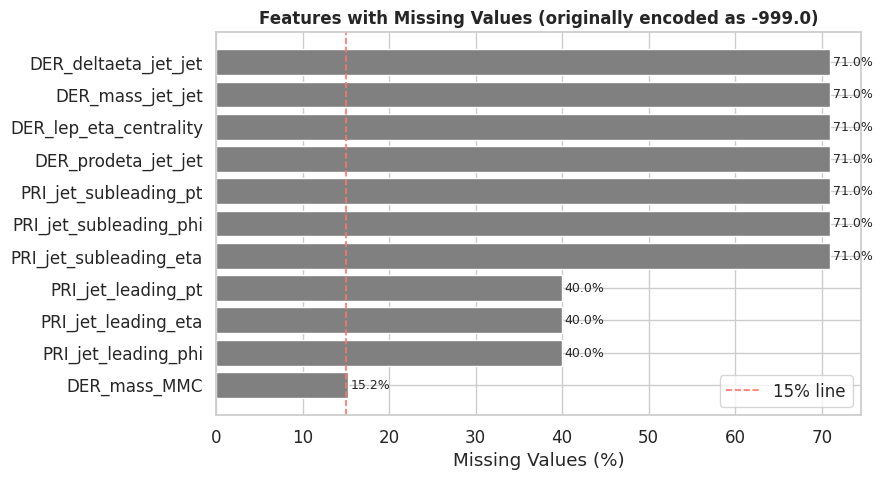


Key observation: ALL missing values are structurally absent - not just
not random measurement errors. They fall into two groups:
Group A: jet-dependent features (undefined when PRI_jet_num < 1 or < 2)
Group B: DER_mass_MMC (undefined when Higgs mass cannot be reconstructed)


In [7]:
# --- VISUALIZE MISSING VALUES ------------------------------------------------------
# A horizontal bar chart is used here rather than a table because it makes the magnitude differences between
# features immediately obvious. The 15% reference line separates DER_mass_MMC (geometrically missing)
# from the jet-dependent features (structurally missing at 40% or 71%).
features_with_na = missing_summary[missing_summary['Missing Count'] > 0].copy()

fig, ax = plt.subplots(figsize=(9, 5))

# [::-1] reverses the order so the longest bar appears at the top
bars = ax.barh(features_with_na.index[::-1], 
               features_with_na['Missing (%)'][::-1],
               color='#808080', edgecolor='white')

ax.set_xlabel('Missing Values (%)')
ax.set_title('Features with Missing Values (originally encoded as -999.0)', 
             fontsize=12, fontweight='bold')
ax.axvline(x=15, color='#FF746C', linestyle='--', lw=1.2, label='15% line')
ax.legend()

# Annotate each bar with its exact percentage value
for bar, pct in zip(bars, features_with_na['Missing (%)'][::-1]):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            f'{pct:.1f}%', va='center', fontsize=9)

plt.tight_layout()
plt.show()


# Missing values fall into two structurally distinct groups:
# Group A - jet-dependent features: undefined when PRI_jet_num < 1 or < 2. These are not measurement
#           failures - the quantity simply does not exist when no jets are detected.
# Group B - DER_mass_MMC: undefined when the Higgs mass cannot be reconstructed from the tau decay topology (~15% of events).
print("\nKey observation: ALL missing values are structurally absent - not just")
print("not random measurement errors. They fall into two groups:")
print("Group A: jet-dependent features (undefined when PRI_jet_num < 1 or < 2)")
print("Group B: DER_mass_MMC (undefined when Higgs mass cannot be reconstructed)")

Class distribution
Signal     (s) : 85,667  (34.27%)
Background (b) : 164,333  (65.73%)
Total          : 250,000

Imbalance ratio (background : signal) = 1.92 : 1


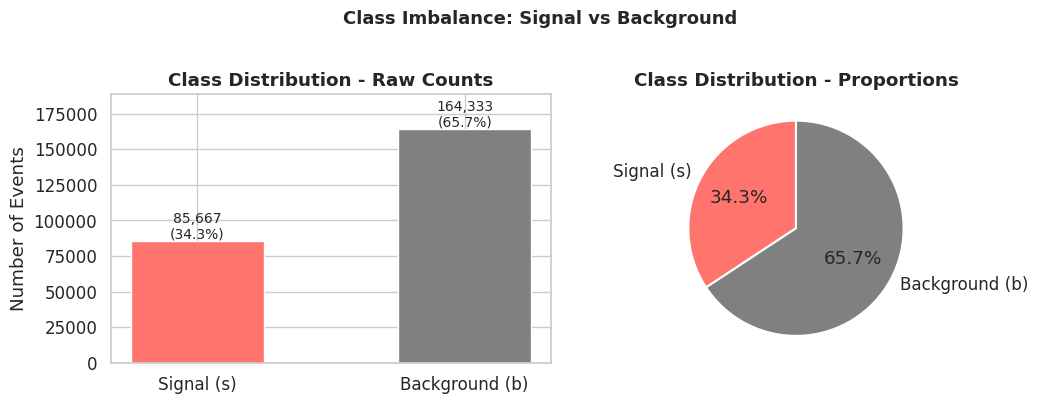

In [8]:
# --- CLASS BALANCE ------------------------------------------------------
# We explicitly compute signal and background counts by name rather than relying on value_counts()
# ordering. value_counts() returns the most frequent class first (background), which caused a bar chart label mismatch in an
# earlier version of this notebook when values were accessed by position.

n_signal     = (train_df['Label'] == 's').sum()
n_background = (train_df['Label'] == 'b').sum()
n_total      = len(train_df)
pct_signal   = n_signal     / n_total * 100
pct_bkg      = n_background / n_total * 100

print("Class distribution")
print("=" * 50)
print(f"Signal     (s) : {n_signal:,}  ({pct_signal:.2f}%)")
print(f"Background (b) : {n_background:,}  ({pct_bkg:.2f}%)")
print(f"Total          : {n_total:,}")
print(f"\nImbalance ratio (background : signal) = "
      f"{n_background/n_signal:.2f} : 1")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

# Named lists ensure signal and background always map to the correct bar/slice
labels = ['Signal (s)', 'Background (b)']
counts = [n_signal, n_background]
pcts   = [pct_signal, pct_bkg]
colors = ['#FF746C', '#808080'] # Personal preference

# Bar chart - explicitly use named values, not positional array
#                   ^ messed me up on the last iteration
ax1.bar(labels, counts, color=colors, edgecolor='white', width=0.5)
ax1.set_title('Class Distribution - Raw Counts', fontweight='bold')
ax1.set_ylabel('Number of Events')
ax1.set_ylim(0, max(counts) * 1.15)
for i, (val, pct) in enumerate(zip(counts, pcts)):
    ax1.text(i, val + 1500, f'{val:,}\n({pct:.1f}%)',
             ha='center', fontsize=10)

# Pie chart - proportional view of same data
ax2.pie(counts,
        labels=labels,
        colors=colors,
        autopct='%1.1f%%',
        startangle=90,
        wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
ax2.set_title('Class Distribution - Proportions', fontweight='bold')

plt.suptitle('Class Imbalance: Signal vs Background',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

In [9]:
# --- TARGET ENCODING ------------------------------------------------------
# The Label column is a string: 's' (signal) or 'b' (background).
# For machine learning -> convert to binary integers.
#   's' (signal)     -> 1
#   'b' (background) -> 0
#
# This encoding is applied to train_clean in a later section.
# Here we just demonstrate what it looks like on a small sample.
#
# Note: Weight is sometimes confused for the target because it is a continuous numeric column. It is nt the target - 
# it is a physics importance weight used only when computing the AMS score.

print("Target Variable: 'Label'")
print("=" * 50)
print("Raw values in dataset:")
print(f"  's' (signal)     -> encoded as  1")
print(f"  'b' (background) -> encoded as  0")
print()

# Show the encoding on first 8 rows
sample = train_df[['EventId', 'Label']].head(8).copy()
sample['Label_encoded'] = (sample['Label'] == 's').astype(int)
print("Sample rows showing encoding:")
print(sample.to_string(index=False))
print()
print("NOTE: The 'Weight' column is NOT the target.")
print("It is a per-event importance weight used when computing the AMS score.")
print(f"  Weight range: [{train_df['Weight'].min():.6f}, {train_df['Weight'].max():.4f}]")
print(f"  Weight mean : {train_df['Weight'].mean():.6f}")

Target Variable: 'Label'
Raw values in dataset:
  's' (signal)     -> encoded as  1
  'b' (background) -> encoded as  0

Sample rows showing encoding:
 EventId Label  Label_encoded
  100000     s              1
  100001     b              0
  100002     b              0
  100003     b              0
  100004     b              0
  100005     b              0
  100006     s              1
  100007     s              1

NOTE: The 'Weight' column is NOT the target.
It is a per-event importance weight used when computing the AMS score.
  Weight range: [0.001502, 7.8225]
  Weight mean : 1.646767


### Summary of Initial Look

| Property | Value |
|---|---|
| Training events | 250,000 |
| Test events | 550,000 |
| Physics features | 30 |
| Features with missing values | 11 |
| Events missing at least one feature | >70% |
| Missing value encoding | -999.0 (sentinel) |
| Signal events | 85,667 (34.27%) |
| Background events | 164,333 (65.73%) |
| Imbalance ratio | ~1.92 : 1 (background:signal) |
| Target encoding | s -> 1,  b -> 0 |

**Key takeaways:**
- Missing values are **not random** - they are structurally driven by `PRI_jet_num`. When a collision produces 0 jets, all jet-related features are physically undefined. This must be handled carefully during cleaning.
- There is a **moderate class imbalance** (~2:1 background to signal). Standard accuracy is misleading here - the AMS metric and event weights are what matter.
- `PRI_jet_num` is the **only categorical feature** (values: 0, 1, 2, 3). All others are continuous floats.
- Outliers are present in many continuous features. These will be addressed in the cleaning step using percentile clipping.

---

## Data Visualization

All 30 features are compared between signal (`s`) and background (`b`) using normalized density histograms, allowing direct visual comparison regardless of class size. Strong separation between the red (signal) and gray (background) curves indicates a useful feature for classification. Missing values are excluded per feature.

In [10]:
# --- PREPARE CLEAN VISUALIZATION DATAFREAME ------------------------------------------------------
# Use train_raw (sentinel already replaced with NaN from the data loading section)
# Add numeric label for easy masking

# Add a numeric label column (1 = signal, 0 = background) for easy boolean masking. We use this instead of the string 'Label' column throughout
# the visualization section to keep filtering syntax clean.
viz_df = train_raw.copy()
viz_df['y'] = (viz_df['Label'] == 's').astype(int)

# Split into two separate DataFrames - one per class. This lets us pass each class directly to histogram functions 
# without repeating the masking logic in every plot.
signal_df     = viz_df[viz_df['y'] == 1]
background_df = viz_df[viz_df['y'] == 0]

# Separate continuous and categorical features using the same data-driven rule from Section 2: ≤10 unique values = categorical.
# PRI_jet_num (4 unique values) will be caught here automatically.
categorical_features = [c for c in feature_cols if viz_df[c].nunique() <= 10]
continuous_features  = [c for c in feature_cols if c not in categorical_features]

print(f"Signal events         : {len(signal_df):,}")
print(f"Background events     : {len(background_df):,}")
print(f"Continuous features   : {len(continuous_features)}")
print(f"Categorical features  : {len(categorical_features)}  -> {categorical_features}")

Signal events         : 85,667
Background events     : 164,333
Continuous features   : 29
Categorical features  : 1  -> ['PRI_jet_num']


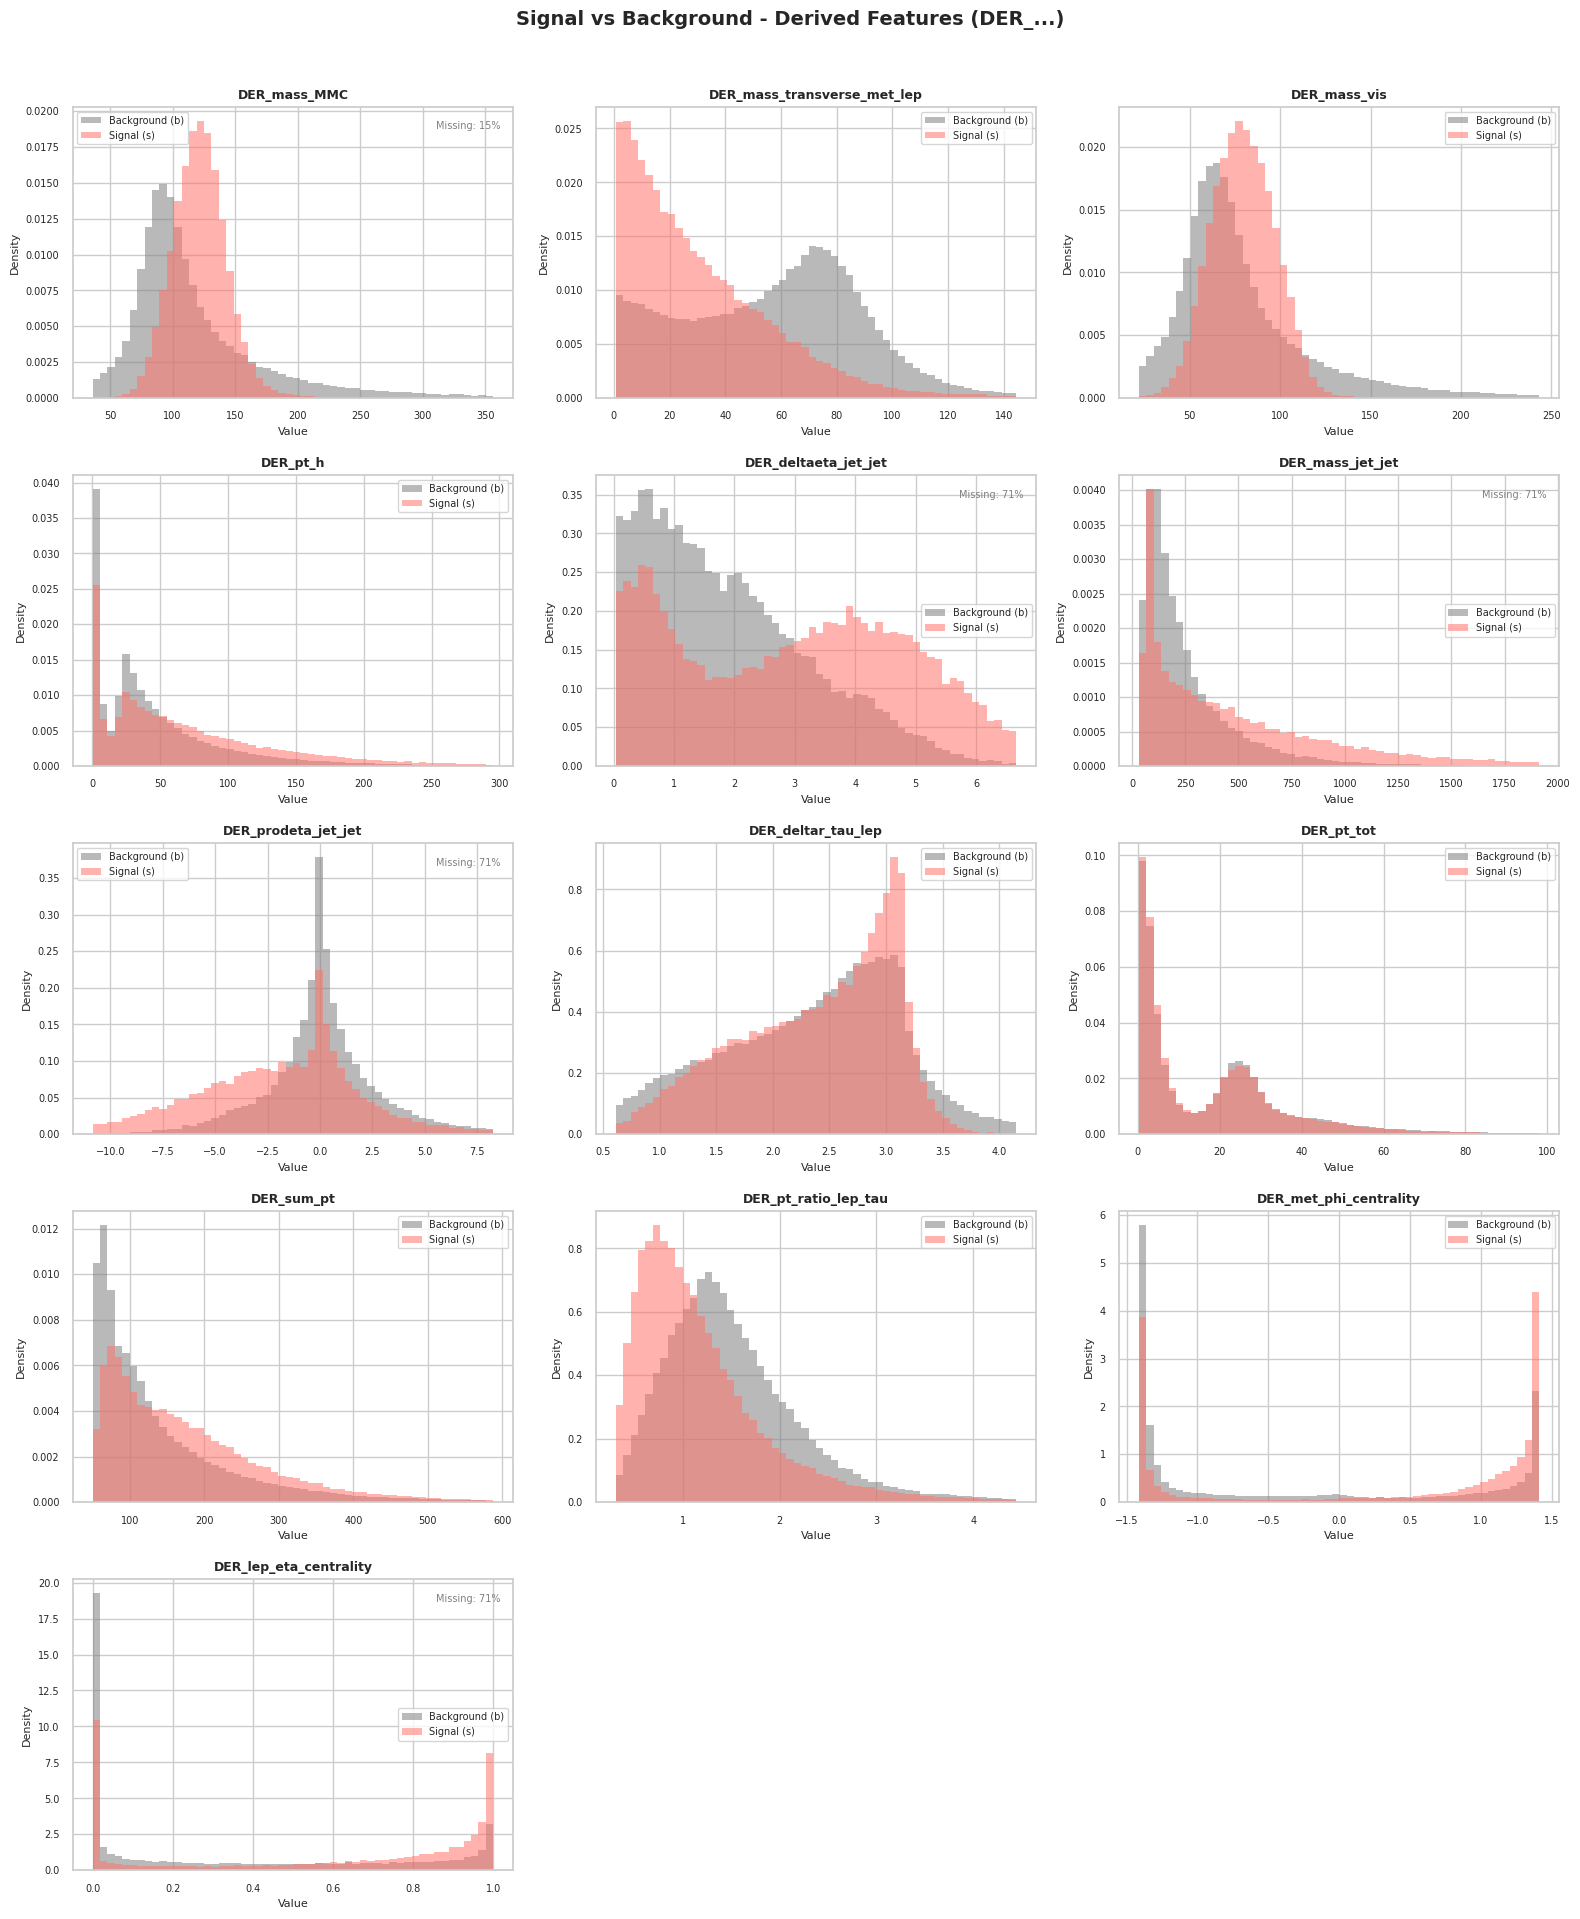

In [11]:
# --- HISTOGRAMS: DERIVED FEATURES (Der_...) ------------------------------------------------------
# Derived features are computed by ATLAS physicists from raw detector measurements. They include invariant masses, momentum ratios, and
# angular separations - quantities specifically designed to capture the physics geometry of each collision event.
#
# For each feature we overlay the signal and background distributions as normalized density histograms so both classes are visually comparable
# regardless of their different raw event counts (85,667 vs 164,333).
#
# Bin edges are clipped to the 1st–99th percentile of the combined distribution. Without clipping, a single extreme outlier can compress
# the entire main distribution into a thin sliver on the left.

der_features = [c for c in continuous_features if c.startswith('DER_')]
n = len(der_features)
ncols = 3
nrows = int(np.ceil(n / ncols)) # enough rows to fit all features at 3 per row

fig, axes = plt.subplots(nrows, ncols, figsize=(16, nrows * 3.8))
fig.suptitle('Signal vs Background - Derived Features (DER_...)', fontsize=14, fontweight='bold', y=1.01)
axes = axes.flatten() # convert 2D array of axes into a flat list for easy iteration

for ax, col in zip(axes, der_features):
    sig_vals = signal_df[col].dropna() # drop NaN so missing events don't
    bkg_vals = background_df[col].dropna() # create a false spike at any value

    # Shared bin edges clipped to 1st–99th percentile to avoid extreme outliers compressing
    # the main distribution
    lo   = pd.concat([sig_vals, bkg_vals]).quantile(0.01)
    hi   = pd.concat([sig_vals, bkg_vals]).quantile(0.99)
    bins = np.linspace(lo, hi, 55)

    # Background plotted first so signal overlays on top
    ax.hist(bkg_vals, bins=bins, density=True, alpha=0.55, color='#808080', label='Background (b)', edgecolor='none')
    ax.hist(sig_vals,  bins=bins, density=True, alpha=0.55, color='#FF746C', label='Signal (s)', edgecolor='none')

    # Overlap: smaller peak / larger peak -> lower = better separation
    ax.set_title(col, fontsize=9, fontweight='bold')
    ax.set_xlabel('Value', fontsize=8)
    ax.set_ylabel('Density', fontsize=8)
    ax.tick_params(labelsize=7)
    ax.legend(fontsize=7)

    # Annotate features that have missing values -> histogram only reflects the subset of events where the value
    # was actually observed, not the full 250,000 events.
    n_missing = train_raw[col].isna().sum()
    if n_missing > 0:
        pct = n_missing / len(train_raw) * 100
        ax.text(0.97, 0.95, f'Missing: {pct:.0f}%',
                transform=ax.transAxes, fontsize=7,
                ha='right', va='top', color='gray')

# Hide any subplot panels that were not assigned a feature
for ax in axes[n:]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()

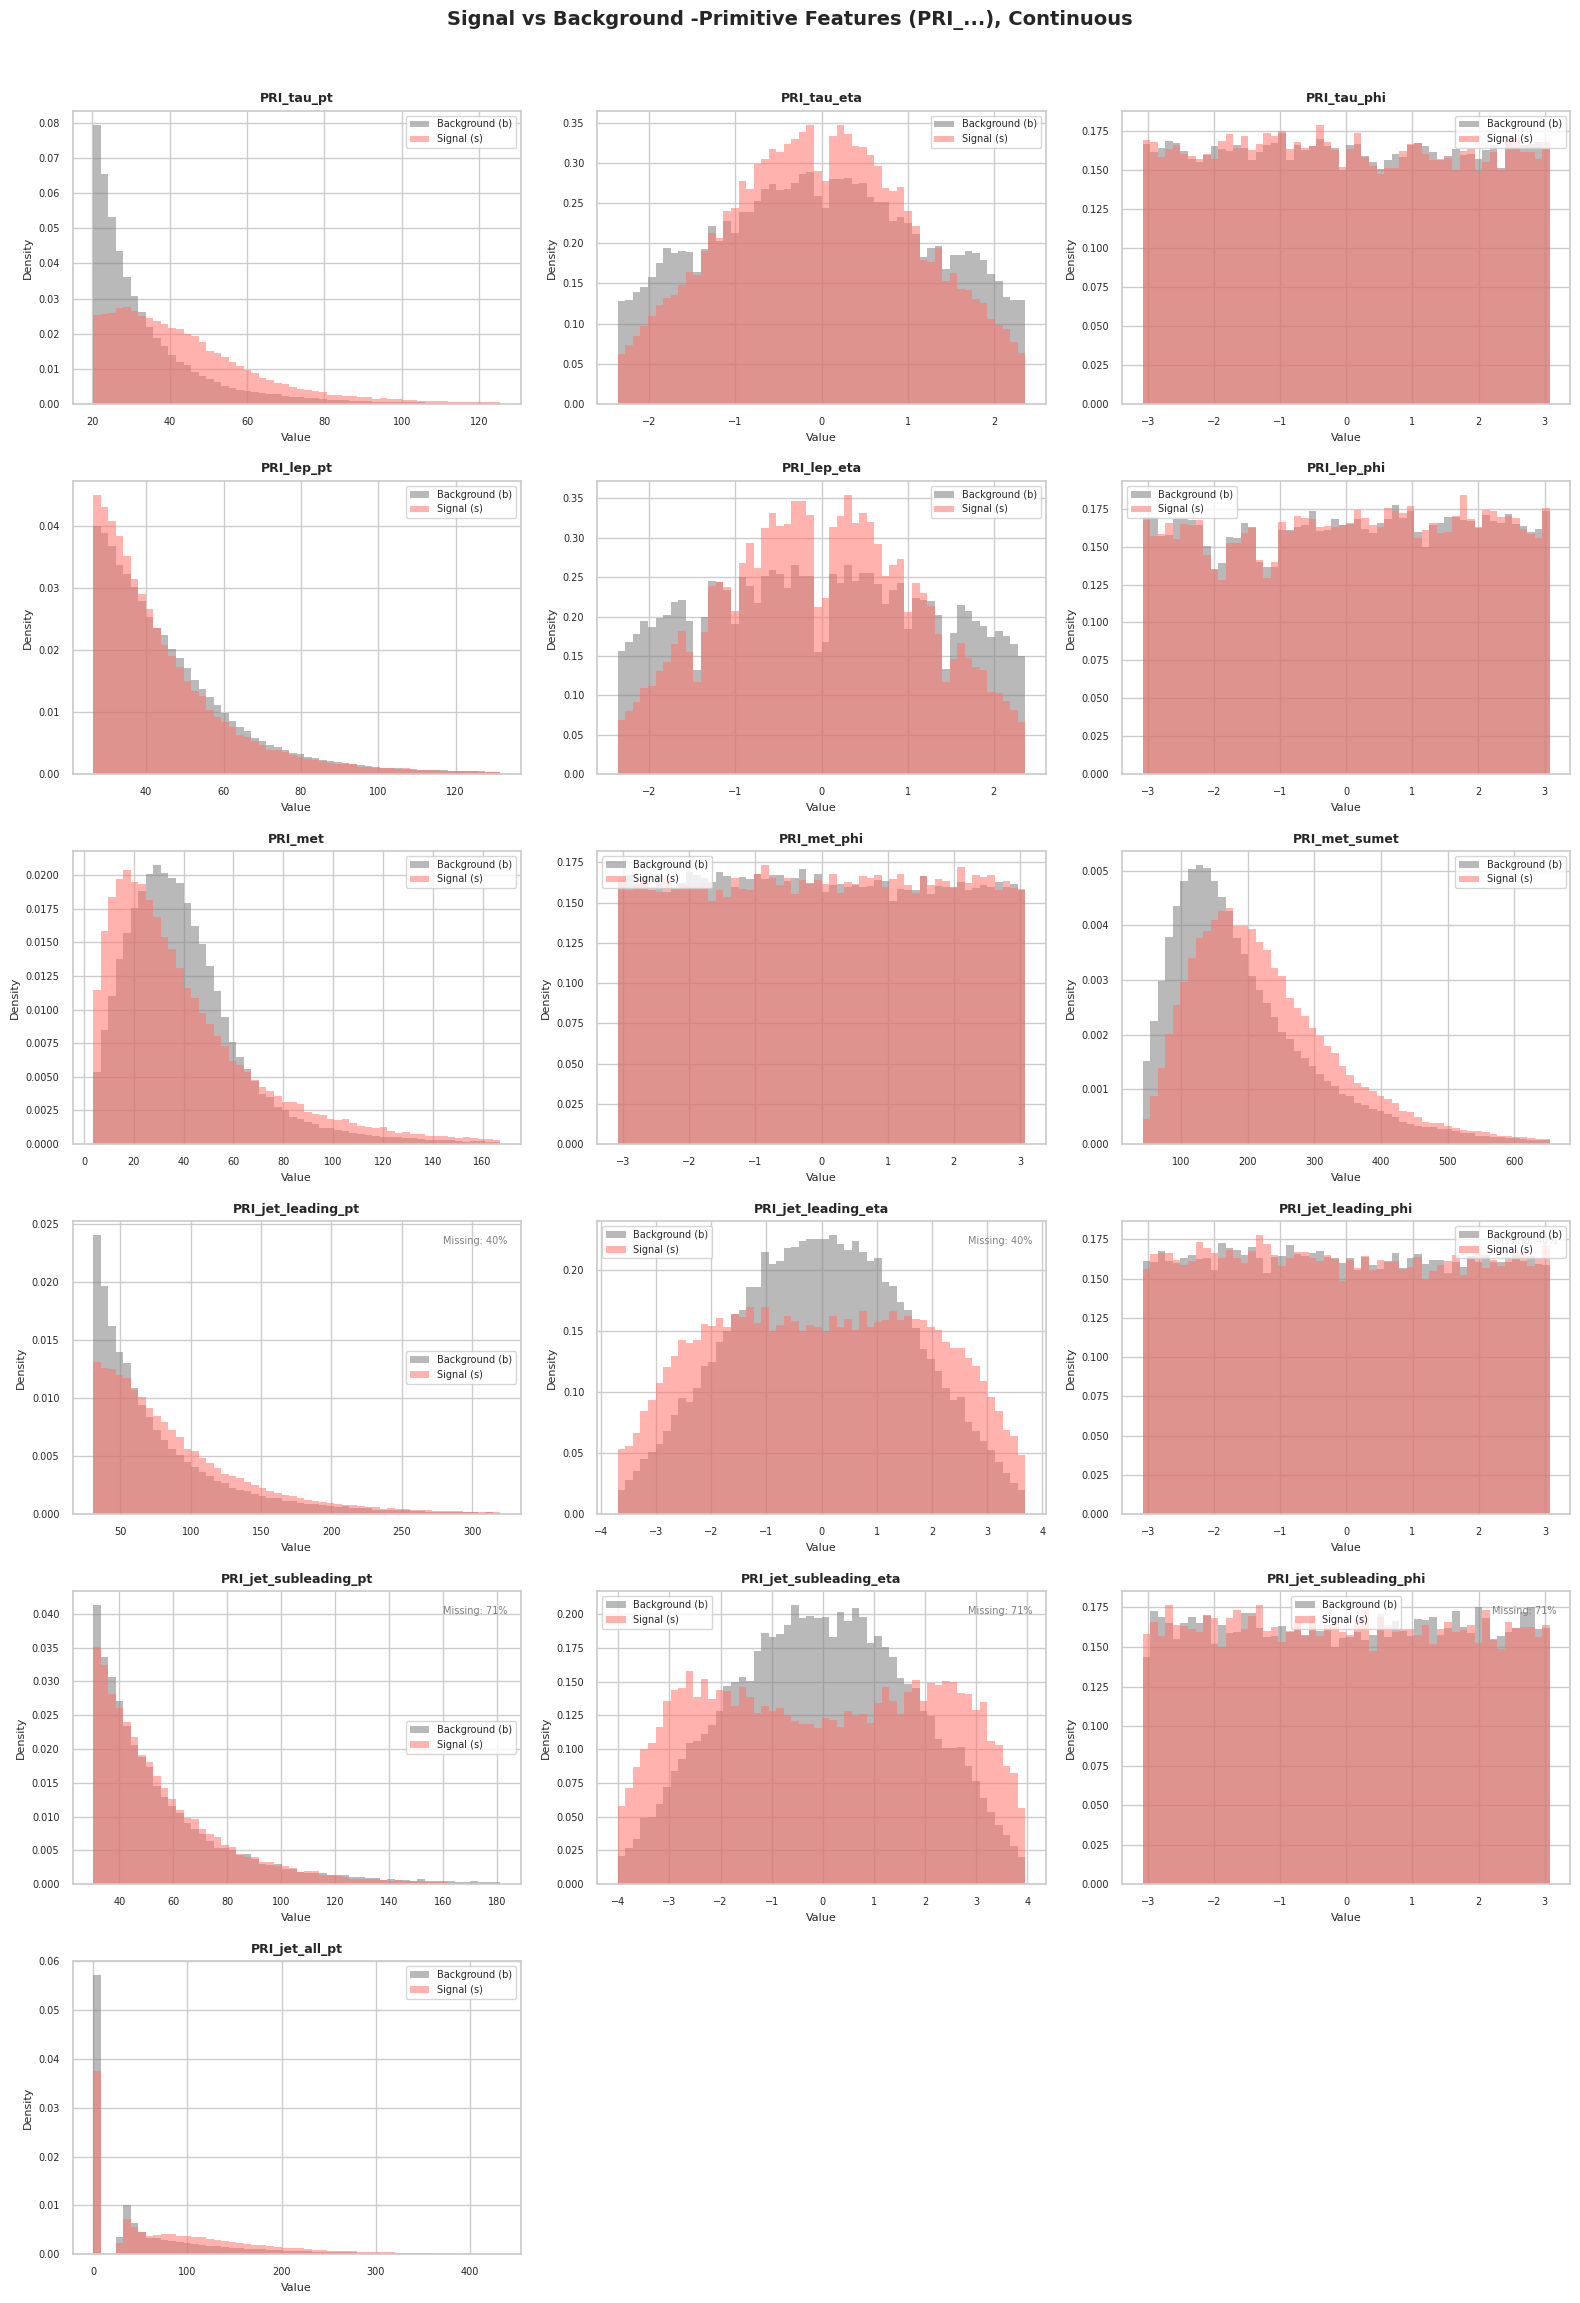

In [12]:
# --- HISTOGRAMS: PRIMITIVE FEATURES (PRI_...) ------------------------------------------------------
# Primitive features are the raw detector measurements - transverse momenta, pseudorapidities, azimuthal angles, and missing transverse energy.
# They have not been transformed or combined by physicists, so they reflect the detector output more directly than the DER features.
#
# PRI_jet_num is intentionally excluded here - as the only categorical feature, a histogram with continuous bins would misrepresent its
# distribution. It is handled separately in the next cell.
#
# The same plotting logic as the DER cell is used for consistency.

pri_features = [c for c in continuous_features if c.startswith('PRI_')]
n = len(pri_features)
ncols = 3
nrows = int(np.ceil(n / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(16, nrows * 3.8))
fig.suptitle('Signal vs Background -Primitive Features (PRI_...), Continuous', fontsize=14, fontweight='bold', y=1.01)
axes = axes.flatten()

for ax, col in zip(axes, pri_features):
    sig_vals = signal_df[col].dropna()
    bkg_vals = background_df[col].dropna()

    lo   = pd.concat([sig_vals, bkg_vals]).quantile(0.01)
    hi   = pd.concat([sig_vals, bkg_vals]).quantile(0.99)
    bins = np.linspace(lo, hi, 55)

    ax.hist(bkg_vals, bins=bins, density=True, alpha=0.55, color='#808080', label='Background (b)', edgecolor='none')
    ax.hist(sig_vals,  bins=bins, density=True, alpha=0.55, color='#FF746C', label='Signal (s)', edgecolor='none')

    ax.set_title(col, fontsize=9, fontweight='bold')
    ax.set_xlabel('Value', fontsize=8)
    ax.set_ylabel('Density', fontsize=8)
    ax.tick_params(labelsize=7)
    ax.legend(fontsize=7)

    # Annotate missing value percentage where applicable (jet-related PRI features are undefined when no jets are detected)
    n_missing = train_raw[col].isna().sum()
    if n_missing > 0:
        pct = n_missing / len(train_raw) * 100
        ax.text(0.97, 0.95, f'Missing: {pct:.0f}%',
                transform=ax.transAxes, fontsize=7,
                ha='right', va='top', color='gray')

for ax in axes[n:]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()

PRI_jet_num - Frequency Table
Label        Background  Signal  Total  Signal %  Background %
PRI_jet_num                                                   
0                 74421   25492  99913     25.51         74.49
1                 49834   27710  77544     35.73         64.27
2                 24645   25734  50379     51.08         48.92
3                 15433    6731  22164     30.37         69.63

Interpretation:
Events with more jets tend to have a different signal/background
ratio, confirming that jet count carries class-relevant information.


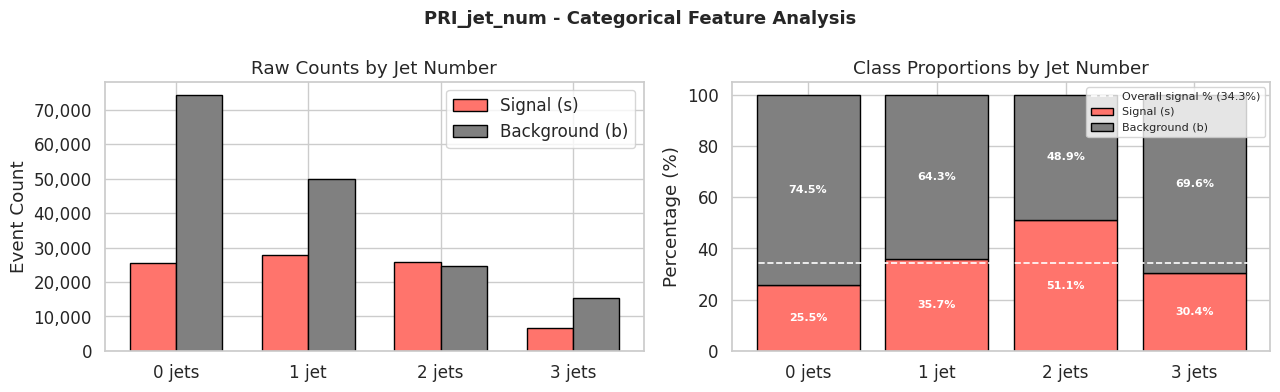

In [13]:
# --- CATEGORICAL FEATURE: PRI_jet_num ------------------------------------------------------
# PRI_jet_num takes only 4 values (0, 1, 2, 3).
# A histogram would be misleading for a discrete variable with so few
# values, so we instead use a frequency table and a grouped bar chart.

jet_raw   = pd.crosstab(viz_df['PRI_jet_num'], viz_df['Label'])
jet_count = jet_raw.rename(columns={'b': 'Background', 's': 'Signal'})
jet_count['Total']           = jet_count['Background'] + jet_count['Signal']
jet_count['Signal %']        = (jet_count['Signal']     / jet_count['Total'] * 100).round(2)
jet_count['Background %']    = (jet_count['Background'] / jet_count['Total'] * 100).round(2)

print("PRI_jet_num - Frequency Table")
print("=" * 50)
print(jet_count.to_string())
print()
print("Interpretation:")
print("Events with more jets tend to have a different signal/background")
print("ratio, confirming that jet count carries class-relevant information.")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('PRI_jet_num - Categorical Feature Analysis', fontsize=13, fontweight='bold')

# Grouped bar chart: raw counts
x    = np.arange(4) # x positions for the 4 jet count categories (0, 1, 2, 3)
w    = 0.35 # bar width - narrow enough that grouped bars don't overlap
sig_counts = jet_count['Signal'].values
bkg_counts = jet_count['Background'].values

# Grouped bar chart: side-by-side signal and background counts per jet number Offset by ±w/2 so both bars are centered on the same x tick
ax1.bar(x - w/2, sig_counts, w, label='Signal (s)', color='#FF746C', edgecolor='black')
ax1.bar(x + w/2, bkg_counts, w, label='Background (b)', color='#808080', edgecolor='black')
ax1.set_xticks(x)
ax1.set_xticklabels(['0 jets', '1 jet', '2 jets', '3 jets'])
ax1.set_ylabel('Event Count')
ax1.set_title('Raw Counts by Jet Number')
ax1.legend()
# Format y-axis with comma separators for readability (e.g. 50,000 not 50000)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda val, _: f'{int(val):,}'))

# Stacked proportional bar chart
sig_pct = jet_count['Signal %'].values
bkg_pct = jet_count['Background %'].values

# Stacked proportional bar chart: signal stacked on bottom, background on top. Each full bar sums to 100% - shows the 
# class split within each jet count group.
ax2.bar(x, sig_pct, label='Signal (s)', color='#FF746C', edgecolor='black')
ax2.bar(x, bkg_pct, bottom=sig_pct, label='Background (b)', color='#808080', edgecolor='black')
ax2.set_xticks(x)
ax2.set_xticklabels(['0 jets', '1 jet', '2 jets', '3 jets'])
ax2.set_ylabel('Percentage (%)')
ax2.set_title('Class Proportions by Jet Number')
# Dashed reference line showing the overall signal % across the full dataset Makes it easy to see which
# jet counts are enriched or depleted in signal
ax2.axhline(y=pct_signal, color='white', linestyle='--', linewidth=1.2, label=f'Overall signal % ({pct_signal:.1f}%)')
ax2.legend(fontsize=8)

# Label each segment with its percentage for direct readability
for i, (s, b) in enumerate(zip(sig_pct, bkg_pct)):
    ax2.text(i, s / 2,        f'{s:.1f}%', ha='center', va='center', fontsize=8, color='white', fontweight='bold')
    ax2.text(i, s + b / 2,    f'{b:.1f}%', ha='center', va='center', fontsize=8, color='white', fontweight='bold')

plt.tight_layout()
plt.show()

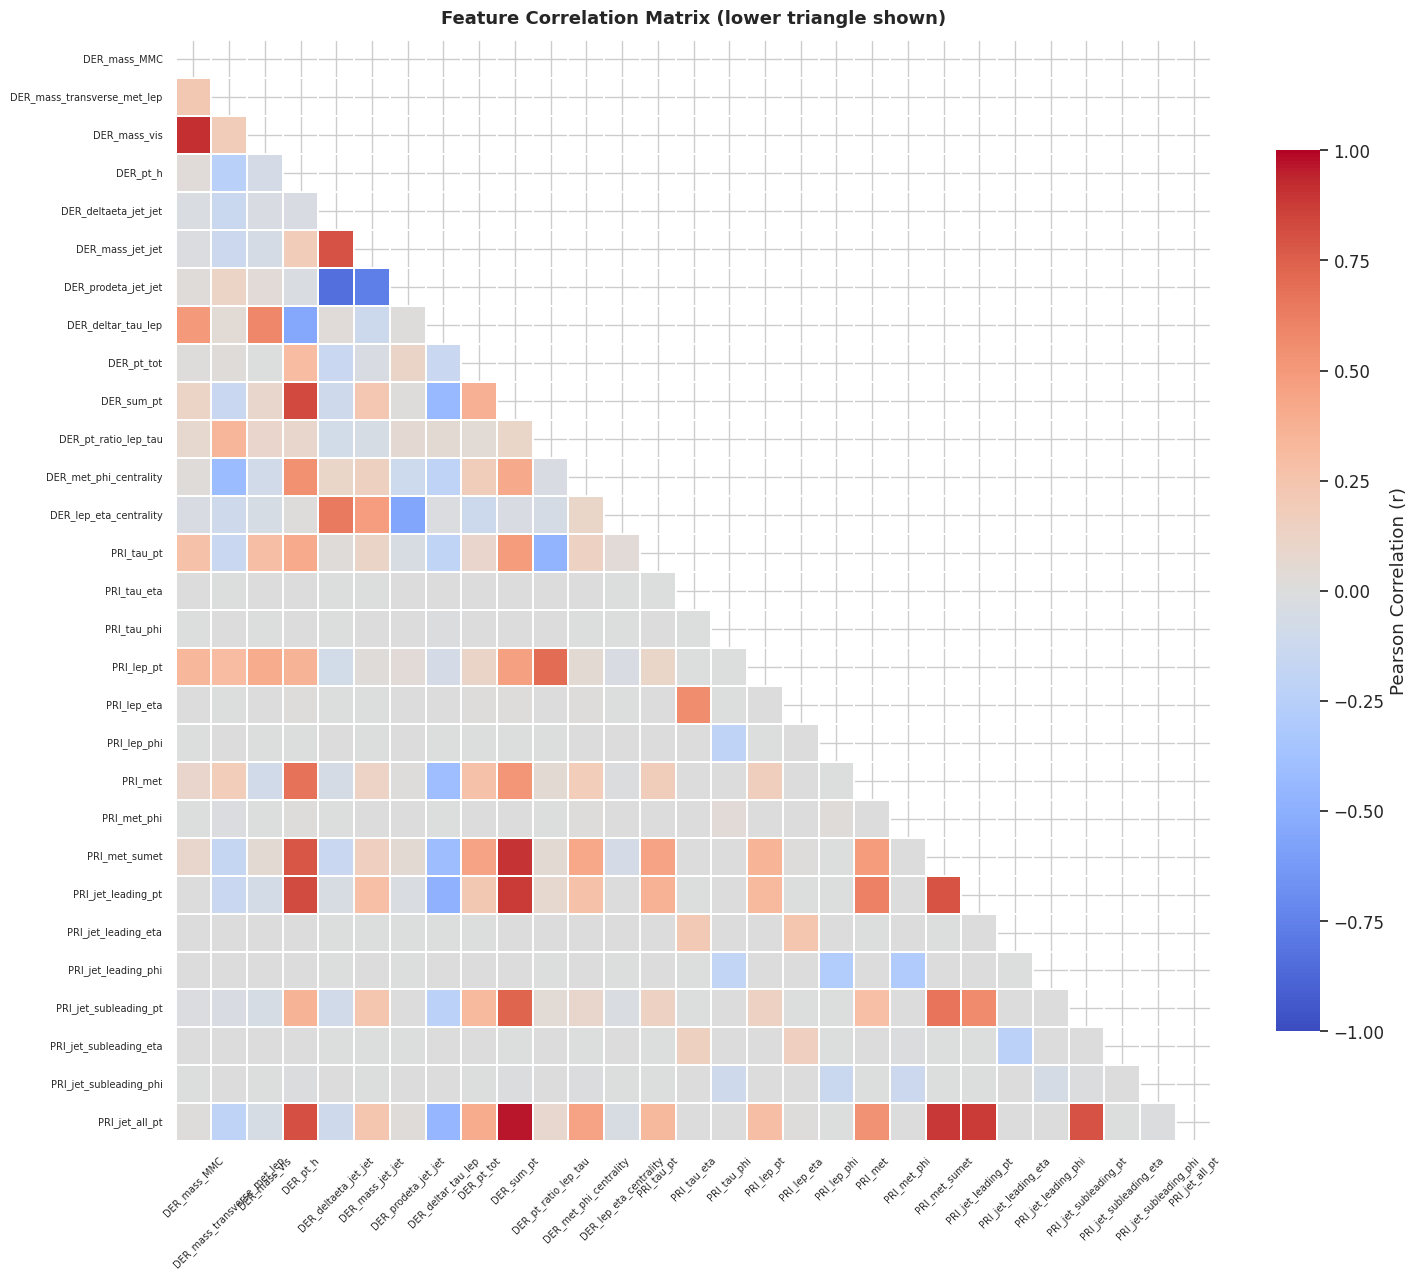

Top 10 most correlated feature pairs:
          Feature A            Feature B  Correlation
     PRI_jet_all_pt           DER_sum_pt     0.965628
       DER_mass_vis         DER_mass_MMC     0.911795
      PRI_met_sumet           DER_sum_pt     0.904481
     PRI_jet_all_pt        PRI_met_sumet     0.884413
 PRI_jet_leading_pt           DER_sum_pt     0.879027
     PRI_jet_all_pt   PRI_jet_leading_pt     0.878347
DER_prodeta_jet_jet DER_deltaeta_jet_jet    -0.835993
         DER_sum_pt             DER_pt_h     0.832733
 PRI_jet_leading_pt             DER_pt_h     0.826278
     PRI_jet_all_pt             DER_pt_h     0.808616


In [14]:
# --- CORRELATION HEATMAP ------------------------------------------------------
# The Pearson correlation matrix shows the linear relationship between every pair of continuous features. Values range from -1 (perfect negative
# correlation) to +1 (perfect positive correlation), with 0 meaning no linear relationship.
#
# Highly correlated feature pairs carry redundant information. While Gradient Boosting handles correlated features without issue, the heatmap helps us
# understand the feature space structure and validates that derived features (DER_...) are mathematically related to the
# primitives (PRI_...) they came from.
#
# The upper triangle is masked to avoid showing each pair twice - the lower triangle alone contains all unique pairwise correlations.
# NaN values are excluded pairwise, meaning each pair uses all events where both features were observed.

corr = viz_df[continuous_features].corr()

fig, ax = plt.subplots(figsize=(15, 13))
mask = np.triu(np.ones_like(corr, dtype=bool))  # upper triangle masked

sns.heatmap(corr, mask=mask, cmap='coolwarm', center=0,
            annot=False, linewidths=0.3,
            vmin=-1, vmax=1, ax=ax,
            cbar_kws={'label': 'Pearson Correlation (r)', 'shrink': 0.8})

ax.set_title('Feature Correlation Matrix (lower triangle shown)',
             fontsize=13, fontweight='bold', pad=12)
ax.tick_params(axis='x', labelsize=7, rotation=45)
ax.tick_params(axis='y', labelsize=7, rotation=0)
plt.tight_layout()
plt.show()

# Extract and rank the top correlated pairs programmatically. .where(~mask) sets the upper triangle to NaN, then .stack() drops NaN
# and reshapes the remaining lower-triangle values into a flat Series.
corr_pairs = (corr.where(~mask)
                  .stack()
                  .reset_index()
                  .rename(columns={'level_0': 'Feature A',
                                   'level_1': 'Feature B',
                                   0:         'Correlation'}))
corr_pairs['abs_corr'] = corr_pairs['Correlation'].abs()
top_pairs = corr_pairs.sort_values('abs_corr', ascending=False).head(10)

print("Top 10 most correlated feature pairs:")
print(top_pairs[['Feature A', 'Feature B', 'Correlation']].to_string(index=False))

### Visualization Observations

Separation is quantified using a **histogram overlap coefficient** - the
shared area between normalized signal and background distributions.
Lower overlap = better class separation.

---

#### Strong Separation (overlap < 0.75) - Most Promising for ML

- **`DER_mass_MMC`** (0.565) - Best overall separator. Signal peaks sharply near 125 GeV while background is broad and diffuse, reflecting the distinct Higgs mass signature.

- **`DER_mass_transverse_met_lep`** (0.606) - Second strongest. Signal mean (32.0 GeV) is nearly half the background mean (58.2 GeV), producing very distinct distributions.

- **`DER_mass_vis`** (0.675) - Separation is shape-driven rather than mean-driven. Signal is tightly peaked (σ = 21.5) while background has along tail (σ = 47.9).

- **`DER_deltaeta_jet_jet`** (0.689) - Signal events show a larger pseudorapidity gap between jets (mean 3.04 vs 1.89), a known signature of vector boson fusion topology. Defined only for >=2 jet events.

- **`DER_met_phi_centrality`** (0.702) - Despite "phi" in the name, this is a centrality measure, not an angle. Signal and background means fall on opposite sides of zero (0.321 vs −0.362).

- **`DER_lep_eta_centrality`** (0.702) - Signal leptons sit more centrally between the two jets (mean 0.595 vs 0.348). Defined only for >=2 jet events.

- **`PRI_tau_pt`** (0.703) - Signal taus carry higher transverse momentum (mean 46.0 vs 34.9 GeV), consistent with the Higgs being more massive than its backgrounds.

- **`DER_prodeta_jet_jet`** (0.704) - Signal jets tend to appear in opposite detector hemispheres (mean −1.994 vs 0.128 for background).

- **`DER_mass_jet_jet`** (0.722) - Strong separation when defined (signal mean 511.7 GeV vs 258.4 GeV), but missing in ~71% of events limits its overall impact.

- **`DER_pt_ratio_lep_tau`** (0.738) - Background events tend to have a more energetic lepton relative to the tau (mean 1.56 vs 1.21).

---

#### Moderate Separation (0.75 – 0.90)

- **`DER_pt_h`** (0.817), **`DER_sum_pt`** (0.802), **`PRI_jet_all_pt`**(0.806) - All measure overall event energy scale. Mild separation with signal events being slightly more energetic. Note that `DER_sum_pt` and `PRI_jet_all_pt` are also highly correlated with each other (r = 0.97).

- **`PRI_met`** (0.844), **`PRI_met_sumet`** (0.834) - Only modest separation despite the physics intuition that signal events should carry more missing energy from neutrinos.

- **`PRI_jet_leading_pt`** (0.864), **`PRI_jet_leading_eta`**, **`PRI_jet_subleading_eta`**, **`PRI_lep_eta`** - Minor shape differences, limited individual discriminating power.

---

#### Weak Separation (overlap > 0.90) - Least Promising

- **`DER_deltar_tau_lep`** (0.903) - Near-identical distributions despite being cited as informative in physics literature. Means differ by only 0.02 (2.386 vs 2.366).

- **`PRI_lep_pt`** (0.952) - Contrary to expectation, background actually has a slightly higher mean lepton pT than signal. Very little discriminating power individually.

- **`DER_pt_tot`** (0.976), **`PRI_jet_subleading_pt`** (0.956) - Effectively no separation.

- **`PRI_tau_phi`, `PRI_lep_phi`, `PRI_met_phi`, `PRI_jet_leading_phi`, `PRI_jet_subleading_phi`** (0.984–0.988) - All flat and identical between classes. Azimuthal symmetry in proton-proton collisions makes φ features physically uninformative.

---

#### Categorical Feature - PRI_jet_num

| Jet Count | Signal % | Background % |
|---|---|---|
| 0 jets | 25.51% | 74.49% |
| 1 jet  | 35.73% | 64.27% |
| 2 jets | **51.08%** | **48.92%** |
| 3 jets | 30.37% | 69.63% |

The 2-jet category is the only group where signal and background are nearly equal - significantly enriched compared to the overall signal rate of 34.27%. The 0-jet category is the most background-dominated at 74.49%. This confirms that `PRI_jet_num` carries meaningful class information beyond just driving the missing value pattern.

---

#### Correlation Observations

The top correlated pairs reveal expected physics relationships:

- **`PRI_jet_all_pt` / `DER_sum_pt`** (r = 0.97) - Near-redundant. Jet pT is a large component of total scalar pT sum.
- **`DER_mass_vis` / `DER_mass_MMC`** (r = 0.91) - Both estimate the Higgs candidate mass via different methods. Both are retained since `DER_mass_MMC` has 15% missing values while `DER_mass_vis` does not.
- **`DER_prodeta_jet_jet` / `DER_deltaeta_jet_jet`** (r = −0.84) - Strong negative correlation expected since one is the product and the other the difference of the same two pseudorapidity values.
- All φ features are near-zero correlated with everything else, consistent with their flat histogram distributions.

Gradient Boosting handles correlated features natively, so no features areremoved - but these relationships are worth noting for any future linear
model or dimensionality reduction attempt.

## Data Cleaning and Preparation for Machine Learning

The raw data requires several cleaning steps before it can enter a model. Each step is applied in a deliberate order, fitted on training data only,
and then applied to the test set to prevent data leakage.

**Steps applied:**
1. Encode the target variable
2. Add missingness indicator flags
3. Impute missing values with the feature median
4. Clip outliers at the 1st / 99th percentile
5. One-hot encode `PRI_jet_num`
6. Apply StandardScaler normalization

In [15]:
# --- WORKING COPIES - NEVER MODIFY train_df OR test_df DIRECTLY ------------------------------------------------------
# train_raw was created in Section 2 with -999.0 already replaced by NaN.
# We create fresh working copies here as the starting point for all cleaning.

train_clean = train_raw.copy()   # has NaN where -999.0 was
test_clean  = test_df.copy()
test_clean[feature_cols] = test_clean[feature_cols].replace(-999.0, np.nan)

print("Working copies created.")
print(f"  train_clean : {train_clean.shape}")
print(f"  test_clean  : {test_clean.shape}")
print(f"\nMissing cells in train_clean : "
      f"{train_clean[feature_cols].isna().sum().sum():,}")
print(f"Missing cells in test_clean  : "
      f"{test_clean[feature_cols].isna().sum().sum():,}")

Working copies created.
  train_clean : (250000, 33)
  test_clean  : (550000, 31)

Missing cells in train_clean : 1,580,052
Missing cells in test_clean  : 3,473,394


In [16]:
# --- 1: ENCODE TARGERT VARIABLE ------------------------------------------------------
# Convert the string label 's' / 'b' to a binary integer. This must be done before anything else so we can use it for
# class-conditional operations if needed.
#   's' (signal)     -> 1
#   'b' (background) -> 0

# (sample == 's') produces a boolean Series; .astype(int) converts True/False to 1/0. This is simpler and less error-prone than using LabelEncoder.
train_clean['y'] = (train_clean['Label'] == 's').astype(int)

print("Target encoding applied:")
print(f"  Signal (s)     -> 1 : {(train_clean['y'] == 1).sum():,} events")
print(f"  Background (b) -> 0 : {(train_clean['y'] == 0).sum():,} events")

Target encoding applied:
  Signal (s)     -> 1 : 85,667 events
  Background (b) -> 0 : 164,333 events


In [17]:
# --- 2: MISSINGNESS INDICATOR FLAGS ------------------------------------------------------
# Missing values in this dataset are NOT random - they are structurally absent based on the number of jets detected (PRI_jet_num).
# If we simply impute and move on, the model loses all information about why those values were missing. A binary flag column preserves that
# information explicitly.
#
# We add one flag per feature that has any missing values.
# Flag = 1 means the original value was missing (i.e. -999.0).
# Flag = 0 means the original value was observed.
#
# IMPORTANT: Flags are computed BEFORE imputation - after imputing, all NaNs are gone and the information is permanently lost.

features_with_missing = [c for c in feature_cols if train_clean[c].isna().any()]

for col in features_with_missing:
    flag_name = col + '_missing'
    # Apply the same flag to both train and test using each set's own NaN pattern
    train_clean[flag_name] = train_clean[col].isna().astype(int)
    test_clean[flag_name]  = test_clean[col].isna().astype(int)

indicator_cols = [c for c in train_clean.columns if c.endswith('_missing')]

print(f"Missingness indicator flags added: {len(indicator_cols)}")
print()
for col in indicator_cols:
    n = train_clean[col].sum()
    pct = n / len(train_clean) * 100
    print(f"  {col:<40} flagged {n:,} events ({pct:.1f}%)")

Missingness indicator flags added: 11

  DER_mass_MMC_missing                     flagged 38,114 events (15.2%)
  DER_deltaeta_jet_jet_missing             flagged 177,457 events (71.0%)
  DER_mass_jet_jet_missing                 flagged 177,457 events (71.0%)
  DER_prodeta_jet_jet_missing              flagged 177,457 events (71.0%)
  DER_lep_eta_centrality_missing           flagged 177,457 events (71.0%)
  PRI_jet_leading_pt_missing               flagged 99,913 events (40.0%)
  PRI_jet_leading_eta_missing              flagged 99,913 events (40.0%)
  PRI_jet_leading_phi_missing              flagged 99,913 events (40.0%)
  PRI_jet_subleading_pt_missing            flagged 177,457 events (71.0%)
  PRI_jet_subleading_eta_missing           flagged 177,457 events (71.0%)
  PRI_jet_subleading_phi_missing           flagged 177,457 events (71.0%)


In [18]:
# -- 3: MEDIAN IMPUTATION ------------------------------------------------------
# We replace remaining NaN values with the median of each feature.
#
# WHY MEDIAN AND NOT MEAN?
# Several features have extreme outliers (confirmed in data load). The mean is pulled toward those extremes, so it would produce an
# imputed value that is not representative of the typical event. The median is robust to outliers and gives a more physically
# sensible fill value.
#
# WHY FIT ON TRAIN ONLY?
# The imputer must be fit exclusively on the training set. If we included test data when computing medians, information from the
# test set would leak into training - an invalid shortcut that would produce an overly optimistic evaluation.

from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='median')

# fit_transform on train: learns the median for each feature, then fills NaN
# transform on test: applies the training medians without refitting
train_clean[feature_cols] = imputer.fit_transform(train_clean[feature_cols])
test_clean[feature_cols]  = imputer.transform(test_clean[feature_cols])

print("Median imputation complete.")
print(f"  Remaining NaN in train_clean : "
      f"{train_clean[feature_cols].isna().sum().sum()}")
print(f"  Remaining NaN in test_clean  : "
      f"{test_clean[feature_cols].isna().sum().sum()}")
print()
print("Imputed medians for previously-missing features:")
for col in features_with_missing:
    idx = list(feature_cols).index(col)
    print(f"  {col:<40} median = {imputer.statistics_[idx]:.4f}")

Median imputation complete.
  Remaining NaN in train_clean : 0
  Remaining NaN in test_clean  : 0

Imputed medians for previously-missing features:
  DER_mass_MMC                             median = 112.4060
  DER_deltaeta_jet_jet                     median = 2.1070
  DER_mass_jet_jet                         median = 225.8850
  DER_prodeta_jet_jet                      median = -0.2440
  DER_lep_eta_centrality                   median = 0.4540
  PRI_jet_leading_pt                       median = 65.5610
  PRI_jet_leading_eta                      median = 0.0000
  PRI_jet_leading_phi                      median = -0.0330
  PRI_jet_subleading_pt                    median = 47.9020
  PRI_jet_subleading_eta                   median = -0.0100
  PRI_jet_subleading_phi                   median = -0.0020


In [19]:
# --- 4: OUTLIER CLIPPING ------------------------------------------------------
# From the feature summary table in Section 2, many continuous features contain extreme outliers. We clip values at the 1st and 99th percentile.
#
# WHY CLIP RATHER THAN REMOVE?
# We cannot remove rows from the test set (we need a prediction for every event), so we also cannot remove rows from the training set - the model
# must handle those regions of feature space. Clipping limits the influence of extreme values without discarding any data.
#
# WHY 1st / 99th PERCENTILE?
# This removes the most extreme 2% of values (1% each tail) while keeping the vast majority of the distribution intact. It is a common
# an conservative choice for physics data which has naturally long tails.
#
# WHY FIT BOUNDS ON TRAIN ONLY?
# Same data leakage reason as imputation - percentiles are computed on training data, then applied to both sets.
#
# NOTE: PRI_jet_num is excluded - it is a discrete variable with only 4 possible values and clipping would be meaningless.

continuous_features = [c for c in feature_cols if c != 'PRI_jet_num']

# Compute clip bounds from the training set
clip_bounds = {}
for col in continuous_features:
    lo = train_clean[col].quantile(0.01)
    hi = train_clean[col].quantile(0.99)
    clip_bounds[col] = (lo, hi)

# Apply clipping to both sets using training-derived bounds
for col in continuous_features:
    lo, hi = clip_bounds[col]
    train_clean[col] = train_clean[col].clip(lower=lo, upper=hi)
    test_clean[col]  = test_clean[col].clip(lower=lo, upper=hi)

print("Outlier clipping applied (1st/99th percentile, train-derived bounds).")
print(f"  Features clipped : {len(continuous_features)}")
print(f"  PRI_jet_num      : excluded (discrete, clipping not applicable)")
print()
print("Example clip bounds (first 5 features):")
for col in continuous_features[:5]:
    lo, hi = clip_bounds[col]
    print(f"  {col:<40} [{lo:.3f},  {hi:.3f}]")

Outlier clipping applied (1st/99th percentile, train-derived bounds).
  Features clipped : 29
  PRI_jet_num      : excluded (discrete, clipping not applicable)

Example clip bounds (first 5 features):
  DER_mass_MMC                             [38.316,  339.844]
  DER_mass_transverse_met_lep              [0.661,  144.514]
  DER_mass_vis                             [21.821,  243.416]
  DER_pt_h                                 [0.378,  295.453]
  DER_deltaeta_jet_jet                     [0.124,  5.882]


In [20]:
# --- 5: ONE-HOT ENCODE PRI_jet_num ------------------------------------------------------
# PRI_jet_num is the only categorical feature (values: 0, 1, 2, 3).
#
# WHY ONE-HOT ENCODE?
# If we leave it as a raw integer, the model treats 3 as "three times more than 1", implying a false ordinal relationship. One-hot encoding
# represents each jet count as an independent binary flag, making no assumption about ordering.
#
# WHY drop_first=False?
# With drop_first=True we drop one category to avoid perfect multicollinearity (the dummy variable trap). However, Gradient Boosting
# is not a linear model and is unaffected by multicollinearity, so keeping all 4 dummies gives the model more explicit information. We keep all 4.
#
# The original PRI_jet_num column is kept for now and will be dropped in the Machine Learning section when we finalize the feature matrix.

ohe_train = pd.get_dummies(train_clean['PRI_jet_num'], prefix='jet_num', dtype=int)
ohe_test  = pd.get_dummies(test_clean['PRI_jet_num'], prefix='jet_num', dtype=int)

# Align columns in case any category is absent in one split
ohe_test = ohe_test.reindex(columns=ohe_train.columns, fill_value=0)

# Append OHE columns to both DataFrames
for col in ohe_train.columns:
    train_clean[col] = ohe_train[col].values
    test_clean[col]  = ohe_test[col].values

ohe_cols = list(ohe_train.columns)
print(f"One-hot encoding applied to PRI_jet_num.")
print(f"  New columns created: {ohe_cols}")
print()
print("Value counts per OHE column (training set):")
for col in ohe_cols:
    n = train_clean[col].sum()
    print(f"  {col} = 1 : {n:,} events ({n/len(train_clean)*100:.1f}%)")

One-hot encoding applied to PRI_jet_num.
  New columns created: ['jet_num_0.0', 'jet_num_1.0', 'jet_num_2.0', 'jet_num_3.0']

Value counts per OHE column (training set):
  jet_num_0.0 = 1 : 99,913 events (40.0%)
  jet_num_1.0 = 1 : 77,544 events (31.0%)
  jet_num_2.0 = 1 : 50,379 events (20.2%)
  jet_num_3.0 = 1 : 22,164 events (8.9%)


In [21]:
# --- 6: STANDARDSCALER NORMALIZATION ------------------------------------------------------
# We standardize all continuous features to zero mean and unit variance.
#
# IS RESCALING NECESSARY FOR GRADIENT BOOSTING?
# Strictly speaking, tree-based models like Gradient Boosting are invariant to monotonic transformations of features - they split on
# rank order, not absolute values. So scaling does NOT affect GBM performance.
#
# WHY DO IT ANYWAY?
# -It makes the magnitude of feature values directly comparable, which aids interpretation and debugging.
# -If we later add or compare any distance-based or linear model (e.g. logistic regression, SVM, neural network), those models
# are highly sensitive to feature scale and would require scaling.
# - It is good practice to standardize as part of a clean, reusable pipeline.
#
# STRATEGY PER FEATURE TYPE:
# - Continuous features (29 features): StandardScaler (mean = 0, std = 1). Appropriate for roughly unimodal distributions
#  that may have outliers (which we have already clipped).
# -PRI_jet_num OHE columns (4 binary flags): NOT scaled. Binary 0/1 columns should not be standardized - it would push
#  them to non-integer values and remove their interpretability.
# -Missingness indicator flags (11 binary flags): NOT scaled. Same reason as OHE columns.
#
# AS ALWAYS: fit on training data only, then apply to both sets.

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# fit_transform learns mean and std from training data and scales it transform applies the same training mean/std to the test set
train_clean[continuous_features] = scaler.fit_transform(
    train_clean[continuous_features])
test_clean[continuous_features]  = scaler.transform(
    test_clean[continuous_features])

print("StandardScaler applied to 29 continuous features.")
print(f"  OHE columns ({len(ohe_cols)}) : NOT scaled (binary flags)")
print(f"  Missingness flags ({len(indicator_cols)}) : NOT scaled (binary flags)")
print()
print("Verification - post-scaling stats for 3 sample features:")
for col in ['DER_mass_MMC', 'PRI_tau_pt', 'DER_pt_h']:
    m = train_clean[col].mean()
    s = train_clean[col].std()
    print(f"  {col:<30} mean = {m:.6f}   std = {s:.6f}")

StandardScaler applied to 29 continuous features.
  OHE columns (4) : NOT scaled (binary flags)
  Missingness flags (11) : NOT scaled (binary flags)

Verification - post-scaling stats for 3 sample features:
  DER_mass_MMC                   mean = -0.000000   std = 1.000002
  PRI_tau_pt                     mean = 0.000000   std = 1.000002
  DER_pt_h                       mean = -0.000000   std = 1.000002


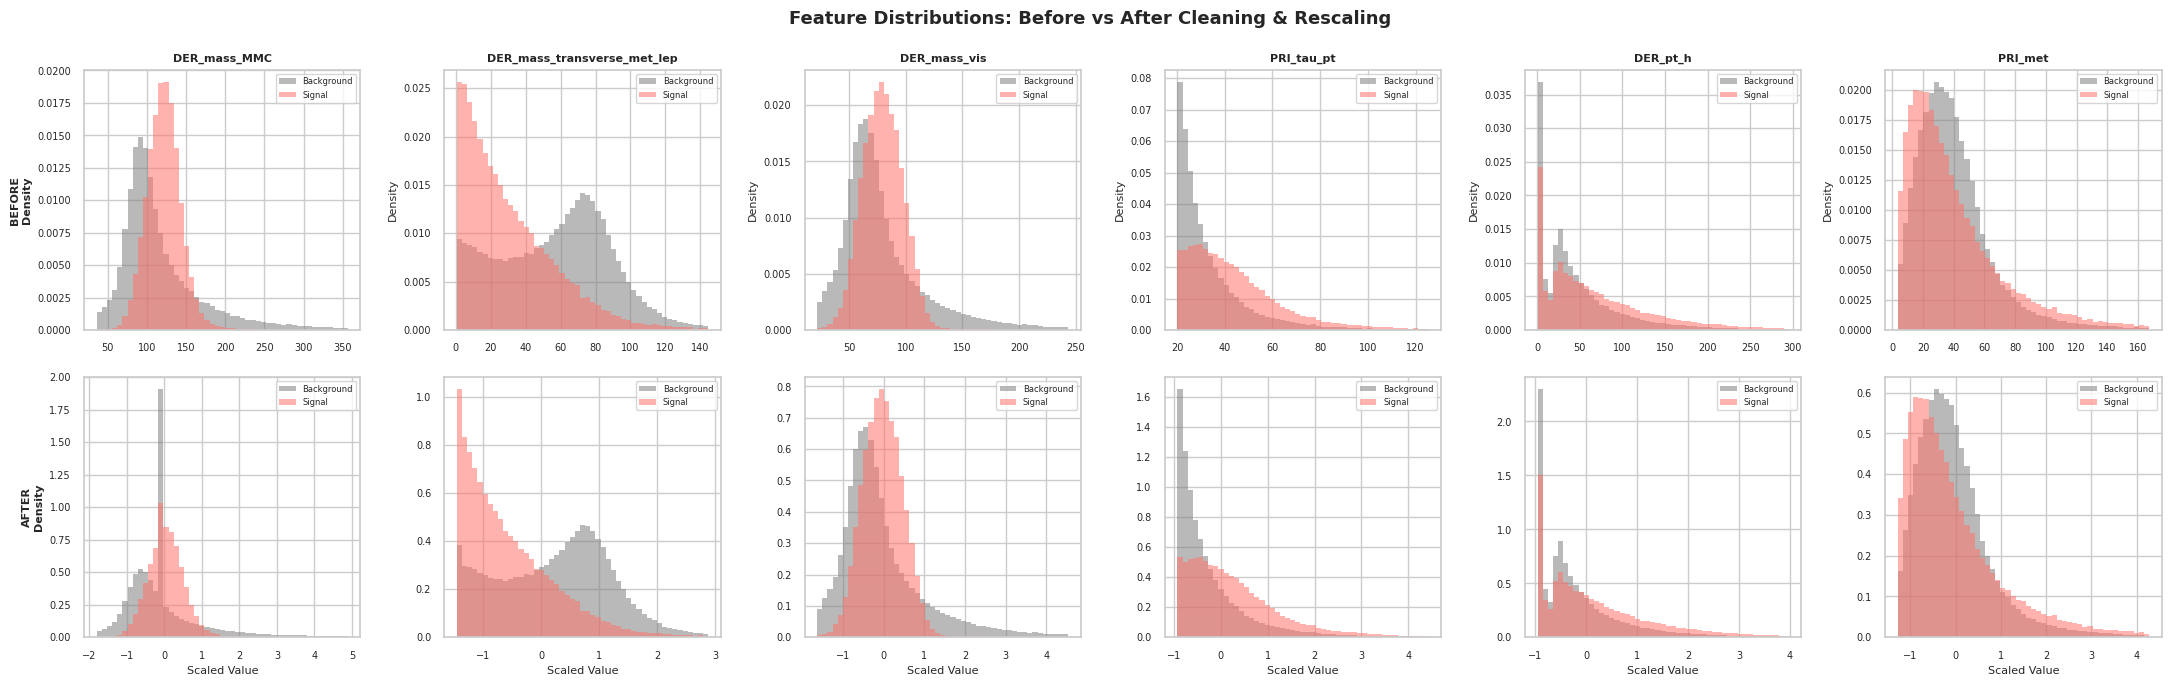

In [22]:
# --- BEFORE VS AFTER: CLEASNING AND RESCALING VISUALIZATION ------------------------------------------------------
# We compare the raw distributions (with -999 already replaced by NaN)
# against the cleaned, clipped, and scaled distributions.
# We show 6 features: 3 strong separators and 3 weaker ones,
# covering both DER and PRI groups.

compare_features = [
    'DER_mass_MMC',
    'DER_mass_transverse_met_lep',
    'DER_mass_vis',
    'PRI_tau_pt',
    'DER_pt_h',
    'PRI_met'
]

fig, axes = plt.subplots(2, 6, figsize=(22, 7))
fig.suptitle('Feature Distributions: Before vs After Cleaning & Rescaling', fontsize=13, fontweight='bold')

for i, col in enumerate(compare_features):
    # --- BEFORE (top row) ---
    ax_top = axes[0, i]
    raw_sig = train_raw[train_raw['Label'] == 's'][col].dropna()
    raw_bkg = train_raw[train_raw['Label'] == 'b'][col].dropna()
    all_raw = pd.concat([raw_sig, raw_bkg])
    lo_r = all_raw.quantile(0.01)
    hi_r = all_raw.quantile(0.99)
    bins_r = np.linspace(lo_r, hi_r, 50)

    ax_top.hist(raw_bkg, bins=bins_r, density=True, alpha=0.55, color='#808080', label='Background', edgecolor='none')
    ax_top.hist(raw_sig, bins=bins_r, density=True, alpha=0.55, color='#FF746C', label='Signal', edgecolor='none')
    ax_top.set_title(col, fontsize=8, fontweight='bold')
    ax_top.set_ylabel('Density', fontsize=8)
    ax_top.tick_params(labelsize=7)
    if i == 0:
        ax_top.set_ylabel('BEFORE\nDensity', fontsize=8, fontweight='bold')
    ax_top.legend(fontsize=6)

    # --- AFTER (bottom row) ---
    ax_bot = axes[1, i]
    clean_sig = train_clean[train_clean['y'] == 1][col]
    clean_bkg = train_clean[train_clean['y'] == 0][col]
    all_clean = pd.concat([clean_sig, clean_bkg])
    lo_c = all_clean.quantile(0.01)
    hi_c = all_clean.quantile(0.99)
    bins_c = np.linspace(lo_c, hi_c, 50)

    ax_bot.hist(clean_bkg, bins=bins_c, density=True, alpha=0.55,color='#808080', label='Background', edgecolor='none')
    ax_bot.hist(clean_sig, bins=bins_c, density=True, alpha=0.55,color='#FF746C', label='Signal',     edgecolor='none')
    ax_bot.set_xlabel('Scaled Value', fontsize=8)
    ax_bot.tick_params(labelsize=7)
    if i == 0:
        ax_bot.set_ylabel('AFTER\nDensity', fontsize=8, fontweight='bold')
    ax_bot.legend(fontsize=6)

plt.tight_layout()
plt.show()

In [23]:
# --- FINAL CLEANED DATASET SUMMARY------------------------------------------------------
# Confirms the shape and composition of train_clean and test_clean after all 6 cleaning steps have been applied.
#
# Total available = 45 columns (29 continuous + 1 PRI_jet_num + 4 OHE + 11 flags) The raw PRI_jet_num column will be dropped in
# ML section when the final feature matrix is assembled, bringing the model input down to 44 features.

all_feature_cols_clean = (continuous_features + ['PRI_jet_num'] + ohe_cols + indicator_cols)

print("CLEANED DATASET SUMMARY")
print("=" * 60)
print(f"Training events          : {len(train_clean):,}")
print(f"Test events              : {len(test_clean):,}")
print()
print("Feature breakdown:")
print(f"  Continuous features    : {len(continuous_features):>3}  (standardized)")
print(f"  PRI_jet_num (raw)      :   1  (will be dropped in ML section)")
print(f"  OHE columns            : {len(ohe_cols):>3}  (not scaled, binary)")
print(f"  Missingness flags      : {len(indicator_cols):>3}  (not scaled, binary)")
print(f"  -----------------------------")
print(f"  Total available        : {len(continuous_features) + 1 + len(ohe_cols) + len(indicator_cols):>3}")
print()
print("Remaining NaN values:")
print(f"  train_clean : {train_clean[feature_cols].isna().sum().sum()}")
print(f"  test_clean  : {test_clean[feature_cols].isna().sum().sum()}")
print()
print("train_clean columns preview:")
print(list(train_clean.columns))

CLEANED DATASET SUMMARY
Training events          : 250,000
Test events              : 550,000

Feature breakdown:
  Continuous features    :  29  (standardized)
  PRI_jet_num (raw)      :   1  (will be dropped in ML section)
  OHE columns            :   4  (not scaled, binary)
  Missingness flags      :  11  (not scaled, binary)
  -----------------------------
  Total available        :  45

Remaining NaN values:
  train_clean : 0
  test_clean  : 0

train_clean columns preview:
['EventId', 'DER_mass_MMC', 'DER_mass_transverse_met_lep', 'DER_mass_vis', 'DER_pt_h', 'DER_deltaeta_jet_jet', 'DER_mass_jet_jet', 'DER_prodeta_jet_jet', 'DER_deltar_tau_lep', 'DER_pt_tot', 'DER_sum_pt', 'DER_pt_ratio_lep_tau', 'DER_met_phi_centrality', 'DER_lep_eta_centrality', 'PRI_tau_pt', 'PRI_tau_eta', 'PRI_tau_phi', 'PRI_lep_pt', 'PRI_lep_eta', 'PRI_lep_phi', 'PRI_met', 'PRI_met_phi', 'PRI_met_sumet', 'PRI_jet_num', 'PRI_jet_leading_pt', 'PRI_jet_leading_eta', 'PRI_jet_leading_phi', 'PRI_jet_subleading_pt'

### Data Cleaning Summary

| Step | What | Why |
|---|---|---|
| **1. Target encoding** | `'s'`->1, `'b'`->0 | ML models require numeric targets |
| **2. Missingness flags** | Binary flag per missing-value feature | Preserves the physics-meaningful pattern of *why* values are absent before imputation erases it |
| **3. Median imputation** | Fill NaN with per-feature training median | Median is robust to the confirmed outliers. Fit on train only to prevent data leakage |
| **4. Outlier clipping** | Clip continuous features to [1st, 99th] percentile | Limits extreme values without discarding events. Bounds from training data only |
| **5. One-hot encoding** | `PRI_jet_num` -> 4 binary columns | Removes false ordinal assumption imposed by keeping it as a raw integer |
| **6. StandardScaler** | Standardize 29 continuous features | Not required for GBM but enables fair comparison with other model types |

**Key principle throughout:** Every fit (imputer medians, clip bounds, scaler mean/std) is computed exclusively on the training set and then applied to the test set - no information from the test set influences any preprocessing decision.

## Machine Learning

### 1. Problem Formulation

Before training, the feature matrix is finalized by removing non-feature
columns, the target is verified, and the labeled data is split into three
non-overlapping subsets for training, validation, and hold-out evaluation.

In [24]:
# --- FINALIZE THE FEATURE MATRIXX ------------------------------------------------------
# Before building X, we drop columns that must not enter the model:
#
#   EventId     -> arbitrary row ID, would introduce spurious patterns
#   Weight      -> physics importance weight, used for AMS only, not a feature
#   Label       -> raw string target, already encoded as 'y'
#   y           -> encoded target, extracted separately as y_all
#   PRI_jet_num -> original categorical column, already replaced by the 4
#                 OHE columns (jet_num_0.0 through jet_num_3.0). Keeping
#                 both would be redundant.

drop_cols_train = ['EventId', 'Weight', 'Label', 'y', 'PRI_jet_num']
drop_cols_test  = ['EventId', 'PRI_jet_num']

# X_all: the full labeled feature matrix (250,000 × 44)
# y_all: the binary target vector
# weights_all: original Kaggle event weights retained for AMS computation
X_all           = train_clean.drop(columns=drop_cols_train, errors='ignore')
y_all           = train_clean['y'].values
weights_all     = train_df['Weight'].values   # original weights for AMS
event_ids_test  = test_df['EventId'].values
X_test_final    = test_clean.drop(columns=drop_cols_test, errors='ignore')

print("FINAL FEATURE MATRIX")
print("=" * 50)
print(f"  Training feature matrix  X_all  : {X_all.shape}")
print(f"  Kaggle test feature matrix      : {X_test_final.shape}")
print(f"  Target vector            y_all  : {y_all.shape}")
print(f"  Event weights                   : {weights_all.shape}")
print()
print(f"  Signal events     : {y_all.sum():,}  ({y_all.mean()*100:.2f}%)")
print(f"  Background events : {(y_all==0).sum():,}  ({(y_all==0).mean()*100:.2f}%)")
print()
print("Columns in final feature matrix:")
for i, col in enumerate(X_all.columns, 1):
    print(f"  {i:2d}. {col}")

FINAL FEATURE MATRIX
  Training feature matrix  X_all  : (250000, 44)
  Kaggle test feature matrix      : (550000, 44)
  Target vector            y_all  : (250000,)
  Event weights                   : (250000,)

  Signal events     : 85,667  (34.27%)
  Background events : 164,333  (65.73%)

Columns in final feature matrix:
   1. DER_mass_MMC
   2. DER_mass_transverse_met_lep
   3. DER_mass_vis
   4. DER_pt_h
   5. DER_deltaeta_jet_jet
   6. DER_mass_jet_jet
   7. DER_prodeta_jet_jet
   8. DER_deltar_tau_lep
   9. DER_pt_tot
  10. DER_sum_pt
  11. DER_pt_ratio_lep_tau
  12. DER_met_phi_centrality
  13. DER_lep_eta_centrality
  14. PRI_tau_pt
  15. PRI_tau_eta
  16. PRI_tau_phi
  17. PRI_lep_pt
  18. PRI_lep_eta
  19. PRI_lep_phi
  20. PRI_met
  21. PRI_met_phi
  22. PRI_met_sumet
  23. PRI_jet_leading_pt
  24. PRI_jet_leading_eta
  25. PRI_jet_leading_phi
  26. PRI_jet_subleading_pt
  27. PRI_jet_subleading_eta
  28. PRI_jet_subleading_phi
  29. PRI_jet_all_pt
  30. DER_mass_MMC_missing

In [25]:
# --- SPLIT INTO TRAIN, VALIDATION, & HOLD-OUT TEST ------------------------------------------------------
# We split the 250,000 labeled events into three subsets:
#
# Train (70%)      : Used to fit the model.
# Validation (15%) : Used during development to tune the threshold and evaluate performance without touching the test set.
# Hold-out test (15%): Set aside until final evaluation. Simulates how the model performs on truly unseen labeled data.
#
# The Kaggle test set (550,000 events) has no labels and is used exclusively to generate the final submission file.
#
# WHY STRATIFY?
# stratify=y ensures each split has the same ~34% / ~66% signal-to- background ratio as the full dataset. Without this, random chance
# could place disproportionate amounts of one class in one split, making metrics unreliable.

from sklearn.model_selection import train_test_split

# First split: 70% train, 30% temp
X_train, X_temp, y_train, y_temp, w_train, w_temp = train_test_split(
    X_all.values, y_all, weights_all,
    test_size=0.30,
    random_state=RANDOM_STATE,
    stratify=y_all
)

# Second split: split the 30% temp evenly into 15% val and 15% holdout
X_val, X_holdout, y_val, y_holdout, w_val, w_holdout = train_test_split(
    X_temp, y_temp, w_temp,
    test_size=0.50,
    random_state=RANDOM_STATE,
    stratify=y_temp
)

print("DATA SPLIT SUMMARY")
print("=" * 55)
print(f"  Train      : {X_train.shape[0]:,} events "
      f"({X_train.shape[0]/len(y_all)*100:.1f}%)  "
      f"| signal: {y_train.mean()*100:.2f}%")
print(f"  Validation : {X_val.shape[0]:,} events "
      f"({X_val.shape[0]/len(y_all)*100:.1f}%)  "
      f"| signal: {y_val.mean()*100:.2f}%")
print(f"  Hold-out   : {X_holdout.shape[0]:,} events "
      f"({X_holdout.shape[0]/len(y_all)*100:.1f}%)  "
      f"| signal: {y_holdout.mean()*100:.2f}%")
print(f"  Kaggle test: {X_test_final.shape[0]:,} events "
      f"(no labels - submission only)")
print()
print("Stratification check (signal % should be ~34.27% in all splits):")
print(f"  Full dataset : {y_all.mean()*100:.2f}%")
print(f"  Train        : {y_train.mean()*100:.2f}%")
print(f"  Validation   : {y_val.mean()*100:.2f}%")
print(f"  Hold-out     : {y_holdout.mean()*100:.2f}%")

DATA SPLIT SUMMARY
  Train      : 175,000 events (70.0%)  | signal: 34.27%
  Validation : 37,500 events (15.0%)  | signal: 34.27%
  Hold-out   : 37,500 events (15.0%)  | signal: 34.27%
  Kaggle test: 550,000 events (no labels - submission only)

Stratification check (signal % should be ~34.27% in all splits):
  Full dataset : 34.27%
  Train        : 34.27%
  Validation   : 34.27%
  Hold-out     : 34.27%


### 2. Train ML Algorithm - Gradient Boosting Classifier

We use scikit-learn's **GradientBoostingClassifier**. Gradient Boosting builds an ensemble of decision trees sequentially, where each new tree corrects the residual errors of the previous ensemble.

It is well suited to this problem because it handles mixed feature types natively, is invariant to feature scale, accepts per-sample weights for class imbalance, and was apparently the dominant approach used by top competitors in the original 2014 Higgs challenge. Hence, we will use it here.

| Parameter | Value | Reasoning |
|---|---|---|
| `n_estimators` | 300 | Enough trees to capture complex patterns |
| `max_depth` | 5 | Moderate depth - captures interactions without overfitting |
| `learning_rate` | 0.1 | Standard shrinkage rate |
| `subsample` | 0.8 | Each tree sees 80% of training data, reducing variance |
| `min_samples_leaf` | 200 | Prevents very small leaves that overfit to noise |
| `max_features` | `'sqrt'` | Column sub-sampling adds diversity across trees |

In [26]:
# --- COMPUTE SAMPLE WEIGHTS ------------------------------------------------------
# The raw Kaggle event weights cannot be fed directly to the model - they span several orders of magnitude and would dominate the fit.
# Instead we rescale them so that:
# - All signal weights sum to 1.0 within the training set
# - All background weights sum to 1.0 within the training set
#
# This achieves two goals simultaneously:
# - Incorporates the physics importance weighting
# - Balances the effective class sizes, addressing the ~2:1 background:signal imbalance

def make_sample_weights(y, w):
    # Rescale event weights so signal and background each sum to 1.0 within the provided subset.
    w_out = w.copy().astype(float)
    sig_mask = (y == 1)
    bkg_mask = (y == 0)
    # Divide each class's weights by that class's total weight
    w_out[sig_mask] = w[sig_mask] / w[sig_mask].sum()
    w_out[bkg_mask] = w[bkg_mask] / w[bkg_mask].sum()
    return w_out

sample_weights_train = make_sample_weights(y_train, w_train)

print("Sample weights computed.")
print(f"  Total signal weight (should = 1.0)     : "
      f"{sample_weights_train[y_train==1].sum():.6f}")
print(f"  Total background weight (should = 1.0) : "
      f"{sample_weights_train[y_train==0].sum():.6f}")
print(f"  Weight range (signal)                  : "
      f"[{sample_weights_train[y_train==1].min():.2e}, "
      f"{sample_weights_train[y_train==1].max():.2e}]")
print(f"  Weight range (background)              : "
      f"[{sample_weights_train[y_train==0].min():.2e}, "
      f"{sample_weights_train[y_train==0].max():.2e}]")

Sample weights computed.
  Total signal weight (should = 1.0)     : 1.000000
  Total background weight (should = 1.0) : 1.000000
  Weight range (signal)                  : [3.10e-06, 3.85e-05]
  Weight range (background)              : [2.23e-07, 2.72e-05]


In [27]:
# --- TRAIN GRADIENT BOOSING CLASSIFIER ------------------------------------------------------
# verbose=1 prints a progress update every 10 trees showing:
# Train Loss    : the loss on the training set at that iteration -should decrease steadily as more trees are added
# OOB Improve   : out-of-bag improvement from subsample=0.8 - a rough estimate of generalization gain per tree
# Remaining Time: estimated time to finish training

from sklearn.ensemble import GradientBoostingClassifier
import time

gbc = GradientBoostingClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.1,
    subsample=0.8,
    min_samples_leaf=200,
    max_features='sqrt',
    random_state=RANDOM_STATE,
    verbose=1
)

print("Training Gradient Boosting Classifier...")
print(f"  Training on {X_train.shape[0]:,} events "
      f"with {X_train.shape[1]} features")
print()

t0 = time.time()
gbc.fit(X_train, y_train, sample_weight=sample_weights_train)
elapsed = time.time() - t0

print(f"\nTraining complete in {elapsed/60:.1f} minutes.")

Training Gradient Boosting Classifier...
  Training on 175,000 events with 44 features

      Iter       Train Loss      OOB Improve   Remaining Time 
         1           1.3048           0.0793            1.54m
         2           1.2468           0.0608            1.43m
         3           1.1931           0.0557            1.51m
         4           1.1404           0.0488            1.49m
         5           1.0951           0.0421            1.47m
         6           1.0629           0.0406            1.45m
         7           1.0242           0.0368            1.47m
         8           0.9955           0.0258            1.48m
         9           0.9659           0.0278            1.48m
        10           0.9434           0.0251            1.47m
        20           0.8025           0.0056            1.44m
        30           0.7426           0.0085            1.38m
        40           0.7054           0.0143            1.32m
        50           0.6844           0.005

### 3. Evaluate Performance on Validation Sample

Three metrics are used:

**Accuracy** - fraction of events correctly classified. Reported for completeness but misleading here due to class imbalance - predicting everything as background gives ~65.7% accuracy with no useful model.

**ROC-AUC** - measures how well the model rank-orders events by signal probability across all thresholds. 0.5 = random, 1.0 = perfect.

**AMS** - the official competition metric. Computed by sweeping the classification threshold and reporting the maximum AMS achieved. This is the number that directly corresponds to the Kaggle leaderboard.

In [28]:
# --- AMS METRIC IMPLEMENTATION ------------------------------------------------------
# Formula from the official Kaggle scoring script:
#   HiggsBosonCompetition_AMSMetric_rev1.py (Joyce Noah-Vanhoukce, 2014)
#   http://proceedings.mlr.press/v42/cowa14.pdf
#
# AMS = sqrt( 2 * ((s + b + b_reg) * ln(1 + s/(b + b_reg)) - s) )
#
#   s     = sum of weights of correctly selected signal events (true positives)
#   b     = sum of weights of incorrectly selected background (false positives)
#   b_reg = 10 (regularization constant - prevents instability when b -> 0)
#
# The official script scores the full 550,000 test events using raw weights. Since we evaluate on a 37,500-event subset, we apply a scale factor
# (250,000 / len(y_true)) to approximate what the score would be on the full training dataset, making validation AMS comparable in magnitude
# to the Kaggle leaderboard score.
#
# IMPORTANT: We use the original Kaggle event weights (w_val, w_holdout), not the rescaled sample weights used during training. The AMS is a
# physics metric that must use the true importance weights.

def compute_ams(y_true, y_proba, weights, threshold=0.5):
    # Compute the AMS at a given classification threshold. Only events with y_proba >= threshold are counted as predicted signal.
    B_REG       = 10.0
    SCALE       = 250000 / len(y_true)   # rescale to full dataset size
    selected    = y_proba >= threshold
    s = weights[selected & (y_true == 1)].sum() * SCALE
    b = weights[selected & (y_true == 0)].sum() * SCALE
    if (b + B_REG) <= 0:
        return 0.0
    return np.sqrt(2 * ((s + b + B_REG) * np.log(1 + s / (b + B_REG)) - s))


def find_best_ams(y_true, y_proba, weights, n_thresholds=200):
    # Sweep thresholds from 0.05 to 0.95 and return the threshold that maximises AMS along with the full sweep for plotting.
    thresholds = np.linspace(0.05, 0.95, n_thresholds)
    ams_values = [compute_ams(y_true, y_proba, weights, t)
                  for t in thresholds]
    best_idx   = int(np.argmax(ams_values))
    return thresholds[best_idx], ams_values[best_idx], thresholds, ams_values


print("AMS metric function defined.")
print("Formula: AMS = sqrt(2 * ((s + b + 10) * ln(1 + s/(b+10)) - s))")
print("s = weighted true positives, b = weighted false positives")

AMS metric function defined.
Formula: AMS = sqrt(2 * ((s + b + 10) * ln(1 + s/(b+10)) - s))
s = weighted true positives, b = weighted false positives


In [29]:
# --- PREDICT ON VALIDATION SET ------------------------------------------------------
# predict_proba returns a (n_events, 2) array - column 0 is P(background), column 1 is P(signal). We take column 1 as the signal probability score.
#
# predict returns hard labels using the default 0.5 threshold. We use these for accuracy and the confusion matrix.
# For AMS we sweep all thresholds using find_best_ams instead.
from sklearn.metrics import (accuracy_score, roc_auc_score,
                             confusion_matrix, classification_report,
                             ConfusionMatrixDisplay, roc_curve)

y_val_proba = gbc.predict_proba(X_val)[:, 1]  # P(signal)
y_val_pred  = gbc.predict(X_val) # hard labels at 0.5

val_acc = accuracy_score(y_val, y_val_pred)
val_auc = roc_auc_score(y_val, y_val_proba)
best_threshold, best_ams, thresh_sweep, ams_sweep = find_best_ams(y_val, y_val_proba, w_val)

print("VALIDATION SET RESULTS")
print("=" * 45)
print(f"  Accuracy       : {val_acc:.4f}")
print(f"  ROC-AUC        : {val_auc:.4f}")
print(f"  Best AMS       : {best_ams:.4f}")
print(f"  Best Threshold : {best_threshold:.3f}")
print()
print("Classification Report:")
print(classification_report(y_val, y_val_pred, target_names=['Background (0)', 'Signal (1)']))

VALIDATION SET RESULTS
  Accuracy       : 0.7952
  ROC-AUC        : 0.8972
  Best AMS       : 3.6217
  Best Threshold : 0.941

Classification Report:
                precision    recall  f1-score   support

Background (0)       0.92      0.76      0.83     24650
    Signal (1)       0.65      0.87      0.74     12850

      accuracy                           0.80     37500
     macro avg       0.78      0.81      0.79     37500
  weighted avg       0.83      0.80      0.80     37500



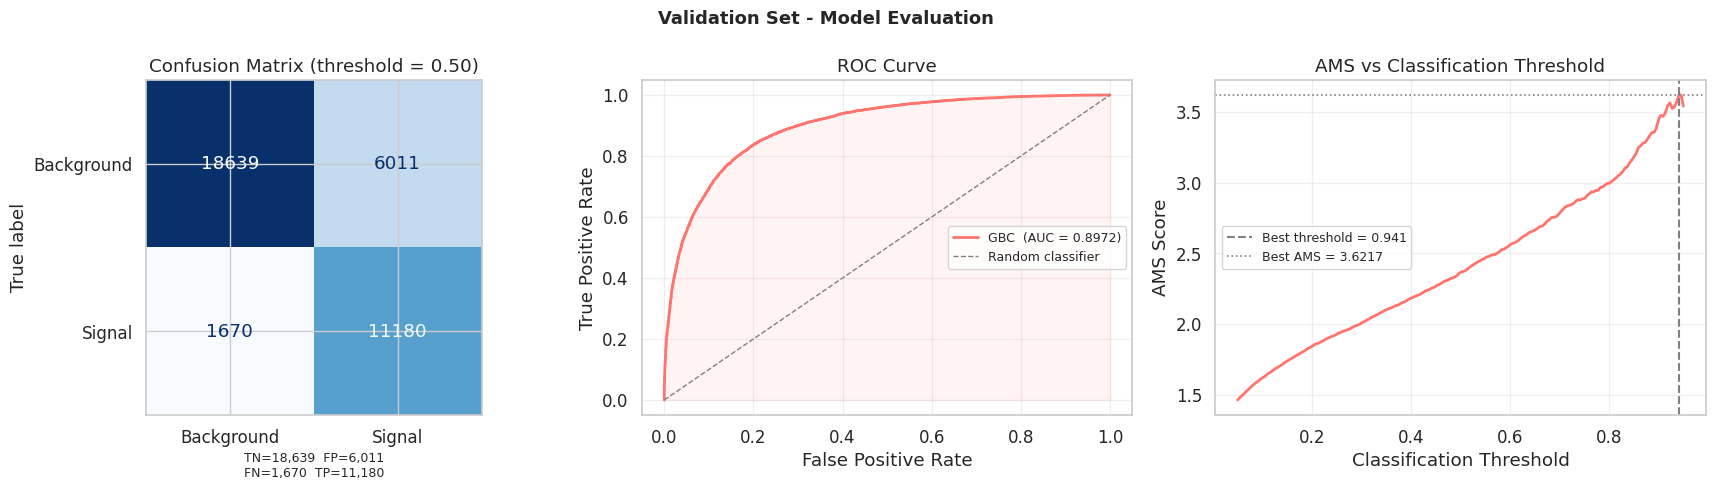

In [30]:
# --- CONFUSION MATRIX & ROC CURVE ------------------------------------------------------
# Three plots are shown side by side:
#
# Confusion Matrix - shows the count of TP, TN, FP, FN at threshold 0.5. Gives a concrete view of where the model makes mistakes.
#
# ROC Curve - plots true positive rate vs false positive rate across all thresholds. AUC is the area under this curve - higher is better.
# The diagonal dashed line represents a random classifier (AUC = 0.5).
#
# AMS vs Threshold - shows how AMS changes as the classification cutoff is swept from 0.05 to 0.95. The peak identifies the optimal threshold
# to use when generating the submission file.

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Validation Set - Model Evaluation', fontsize=13, fontweight='bold')

# -Confusion matrix -
cm = confusion_matrix(y_val, y_val_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Background', 'Signal'])
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Confusion Matrix (threshold = 0.50)')

tn, fp, fn, tp = cm.ravel()
axes[0].set_xlabel(f"TN={tn:,}  FP={fp:,}\nFN={fn:,}  TP={tp:,}", fontsize=9)

# - ROC Curve -
fpr, tpr, _ = roc_curve(y_val, y_val_proba)
axes[1].plot(fpr, tpr, color='#FF746C', lw=2, label=f'GBC  (AUC = {val_auc:.4f})')
axes[1].plot([0, 1], [0, 1], color='#808080', lw=1, linestyle='--', label='Random classifier')
axes[1].fill_between(fpr, tpr, alpha=0.08, color='#FF746C')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve')
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

# - AMS vs Threshold sweep -
# The peak of this curve is the threshold used in the submission file
axes[2].plot(thresh_sweep, ams_sweep, color='#FF746C', lw=2)
axes[2].axvline(best_threshold, color='#808080', linestyle='--', lw=1.5, label=f'Best threshold = {best_threshold:.3f}')
axes[2].axhline(best_ams, color='#808080', linestyle=':', lw=1.2, label=f'Best AMS = {best_ams:.4f}')
axes[2].set_xlabel('Classification Threshold')
axes[2].set_ylabel('AMS Score')
axes[2].set_title('AMS vs Classification Threshold')
axes[2].legend(fontsize=9)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

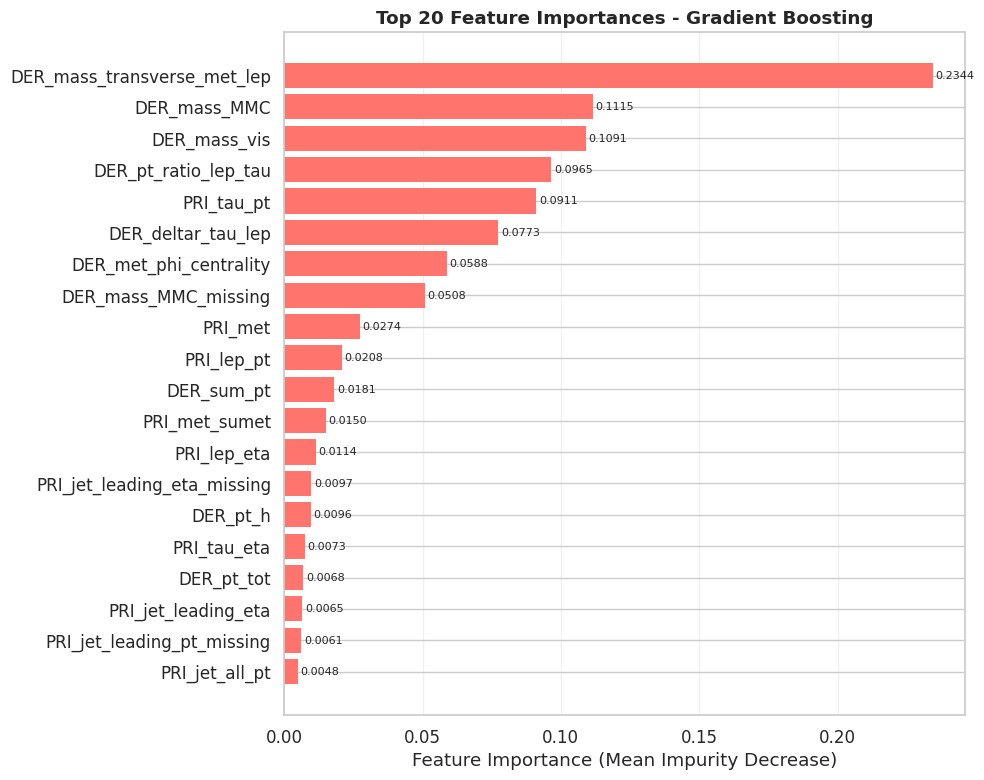

Top 15 features by importance:
                    Feature  Importance
DER_mass_transverse_met_lep    0.234409
               DER_mass_MMC    0.111476
               DER_mass_vis    0.109068
       DER_pt_ratio_lep_tau    0.096518
                 PRI_tau_pt    0.091053
         DER_deltar_tau_lep    0.077287
     DER_met_phi_centrality    0.058772
       DER_mass_MMC_missing    0.050768
                    PRI_met    0.027364
                 PRI_lep_pt    0.020753
                 DER_sum_pt    0.018068
              PRI_met_sumet    0.014963
                PRI_lep_eta    0.011381
PRI_jet_leading_eta_missing    0.009717
                   DER_pt_h    0.009607

Bottom 5 features (least important):
                       Feature  Importance
                   jet_num_2.0    0.000064
PRI_jet_subleading_eta_missing    0.000048
DER_lep_eta_centrality_missing    0.000048
   DER_prodeta_jet_jet_missing    0.000038
      DER_mass_jet_jet_missing    0.000023


In [31]:
# --- FEATIRE IMPORTANCE ------------------------------------------------------
# Gradient Boosting computes feature importance as the total reduction in the training loss (impurity) attributed to each feature across
# all trees and all splits. Higher = more important.
#
# This gives us a data-driven confirmation of the visual separation analysis from Section 3.

feature_names  = list(X_all.columns)
importances    = gbc.feature_importances_
fi_df = (pd.DataFrame({'Feature': feature_names, 'Importance': importances})
           .sort_values('Importance', ascending=False)
           .reset_index(drop=True))

# Plot top 20
top_n = 20
plot_df = fi_df.head(top_n).iloc[::-1]   # reverse for horizontal bar

fig, ax = plt.subplots(figsize=(10, 8))
bars = ax.barh(plot_df['Feature'], plot_df['Importance'], color='#FF746C', edgecolor='none')
ax.set_xlabel('Feature Importance (Mean Impurity Decrease)')
ax.set_title(f'Top {top_n} Feature Importances - Gradient Boosting', fontweight='bold')
ax.grid(axis='x', alpha=0.3)

# Label each bar with its value
for bar, val in zip(bars, plot_df['Importance']):
    ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height() / 2, f'{val:.4f}', va='center', fontsize=8)

plt.tight_layout()
plt.show()

print("Top 15 features by importance:")
print(fi_df.head(15).to_string(index=False))
print()
print("Bottom 5 features (least important):")
print(fi_df.tail(5).to_string(index=False))

In [32]:
# --- HOLD-OUT TEST SET EVAL ------------------------------------------------------
# The hold-out set was not used during training or threshold selection.
# It gives an unbiased estimate of how the model generalizes.

y_holdout_proba = gbc.predict_proba(X_holdout)[:, 1]
y_holdout_pred  = (y_holdout_proba >= best_threshold).astype(int)

holdout_acc = accuracy_score(y_holdout, y_holdout_pred)
holdout_auc = roc_auc_score(y_holdout, y_holdout_proba)
_, holdout_ams, _, _ = find_best_ams(y_holdout, y_holdout_proba, w_holdout)

print("HOLD-OUT TEST SET RESULTS")
print("=" * 45)
print(f"  Accuracy       : {holdout_acc:.4f}")
print(f"  ROC-AUC        : {holdout_auc:.4f}")
print(f"  Best AMS       : {holdout_ams:.4f}")
print()
print("Consistency check (validation vs hold-out):")
print(f"  Accuracy  - val: {val_acc:.4f}  |  holdout: {holdout_acc:.4f}  "
      f"|  Δ = {abs(val_acc - holdout_acc):.4f}")
print(f"  ROC-AUC   - val: {val_auc:.4f}  |  holdout: {holdout_auc:.4f}  "
      f"|  Δ = {abs(val_auc - holdout_auc):.4f}")
print(f"  AMS       - val: {best_ams:.4f}  |  holdout: {holdout_ams:.4f}  "
      f"|  Δ = {abs(best_ams - holdout_ams):.4f}")
print()
print("Small deltas between validation and hold-out confirm the model")
print("generalizes well and is not overfit to the training data.")

HOLD-OUT TEST SET RESULTS
  Accuracy       : 0.7769
  ROC-AUC        : 0.9007
  Best AMS       : 3.6109

Consistency check (validation vs hold-out):
  Accuracy  - val: 0.7952  |  holdout: 0.7769  |  Δ = 0.0183
  ROC-AUC   - val: 0.8972  |  holdout: 0.9007  |  Δ = 0.0036
  AMS       - val: 3.6217  |  holdout: 3.6109  |  Δ = 0.0108

Small deltas between validation and hold-out confirm the model
generalizes well and is not overfit to the training data.


### 4. Apply ML to the Challenge Test Set

The trained model is applied to all 550,000 unlabeled Kaggle test events to generate the final submission file. The optimal threshold identified on the validation set is used to assign the final `'s'` or `'b'` label to each event.

In [33]:
# --- GENERATE KAGGLE SUBMISSION FILE ------------------------------------------------------
# The Kaggle submission format requires exactly three columns:
#
# EventId   : the original event identifier from test.csv
#
# RankOrder : an integer ranking of ALL 550,000 test events from most background-like (rank 1) to most signal-like (rank 550,000).
# Kaggle sweeps this ranking at every possible threshold and reports the maximum AMS achieved - so the quality of the
# ranking matters as much as the threshold.
#
# Class     : 's' or 'b' at the chosen threshold. We use the threshold that maximised AMS on the validation set.

# Predict signal probability for all 550,000 test events
test_proba = gbc.predict_proba(X_test_final.values)[:, 1]

# RankOrder: rank from most background-like (1) to most signal-like (550000)
rank_order = test_proba.argsort().argsort() + 1   # 1-indexed

# Apply optimal threshold from validation sweep
predicted_class = np.where(test_proba >= best_threshold, 's', 'b')

submission_df = pd.DataFrame({
    'EventId'   : event_ids_test,
    'RankOrder' : rank_order,
    'Class'     : predicted_class
})

submission_df.to_csv('submission.csv', index=False)

print("Submission file written: submission.csv")
print()
print(f"  Total test events    : {len(submission_df):,}")
print(f"  Predicted Signal (s) : {(predicted_class=='s').sum():,} "
      f"({(predicted_class=='s').mean()*100:.2f}%)")
print(f"  Predicted Bkg    (b) : {(predicted_class=='b').sum():,} "
      f"({(predicted_class=='b').mean()*100:.2f}%)")
print(f"  Threshold used       : {best_threshold:.3f}")
print(f"  RankOrder range      : [{rank_order.min()}, {rank_order.max()}]")
print()
print("Preview of submission file:")
submission_df.head(10)

Submission file written: submission.csv

  Total test events    : 550,000
  Predicted Signal (s) : 79,487 (14.45%)
  Predicted Bkg    (b) : 470,513 (85.55%)
  Threshold used       : 0.941
  RankOrder range      : [1, 550000]

Preview of submission file:


,EventId,RankOrder,Class
0,350000,7287,b
1,350001,221951,b
2,350002,391547,b
3,350003,485648,s
4,350004,101049,b
5,350005,183314,b
6,350006,188934,b
7,350007,4550,b
8,350008,81614,b
9,350009,511032,s


In [34]:
# --- VALIDATE SUBMISSION FORMAT ------------------------------------------------------
# Kaggle will reject a submission that does not meet format requirements.
# We check all conditions before uploading.
#
# Key checks:
# - Exactly 3 columns with correct names
# - Exactly 550,000 rows (one per test event)
# - Class values are only 's' or 'b'
# - RankOrder contains every integer from 1 to 550,000 exactly once
# - No missing values anywhere in the file

sub_check = pd.read_csv('submission.csv')

checks = {
    'Has exactly 3 columns'          : set(sub_check.columns) == {'EventId', 'RankOrder', 'Class'},
    'Row count = 550,000'            : len(sub_check) == 550000,
    'Class values only s or b'       : sub_check['Class'].isin(['s','b']).all(),
    'RankOrder values are unique'    : sub_check['RankOrder'].nunique() == len(sub_check),
    'RankOrder starts at 1'          : sub_check['RankOrder'].min() == 1,
    'RankOrder ends at 550,000'      : sub_check['RankOrder'].max() == len(sub_check),
    'No missing values in submission': sub_check.isna().sum().sum() == 0,
}

print("SUBMISSION VALIDATION")
print("=" * 50)
all_passed = True
for check, result in checks.items():
    status = "PASS" if result else "FAIL"
    print(f"  {status}  {check}")
    if not result:
        all_passed = False

print()
if all_passed:
    print("All checks passed - submission.csv is ready to upload to Kaggle.")
else:
    print("One or more checks failed - review the submission file before uploading.")

SUBMISSION VALIDATION
  PASS  Has exactly 3 columns
  PASS  Row count = 550,000
  PASS  Class values only s or b
  PASS  RankOrder values are unique
  PASS  RankOrder starts at 1
  PASS  RankOrder ends at 550,000
  PASS  No missing values in submission

All checks passed - submission.csv is ready to upload to Kaggle.


In [35]:
# --- FINAL PROJECT SUMMARY ------------------------------------------------------
print("PROJECT SUMMARY - HIGGS BOSON ML CHALLENGE")
print("=" * 50)
print()
print("Dataset")
print(f"  Training events  : 250,000")
print(f"  Test events      : 550,000")
print(f"  Features (final) : {X_all.shape[1]}")
print(f"    -> 29 continuous (standardized)")
print(f"    -> {len(ohe_cols)} OHE columns (PRI_jet_num)")
print(f"    -> {len(indicator_cols)} missingness indicator flags")
print()
print("Model: GradientBoostingClassifier")
print(f"  n_estimators   : 300")
print(f"  max_depth      : 5")
print(f"  learning_rate  : 0.1")
print(f"  subsample      : 0.8")
print(f"  min_samples_leaf: 200")
print()
print("Performance")
print(f"  {'Metric':<15} {'Validation':>12} {'Hold-out':>12}")
print(f"  {'-'*40}")
print(f"  {'Accuracy':<15} {val_acc:>12.4f} {holdout_acc:>12.4f}")
print(f"  {'ROC-AUC':<15} {val_auc:>12.4f} {holdout_auc:>12.4f}")
print(f"  {'AMS':<15} {best_ams:>12.4f} {holdout_ams:>12.4f}")
print()
print(f"  Optimal threshold : {best_threshold:.3f}")
print(f"  Submission file   : submission.csv")
print("=" * 50)

PROJECT SUMMARY - HIGGS BOSON ML CHALLENGE

Dataset
  Training events  : 250,000
  Test events      : 550,000
  Features (final) : 44
    -> 29 continuous (standardized)
    -> 4 OHE columns (PRI_jet_num)
    -> 11 missingness indicator flags

Model: GradientBoostingClassifier
  n_estimators   : 300
  max_depth      : 5
  learning_rate  : 0.1
  subsample      : 0.8
  min_samples_leaf: 200

Performance
  Metric            Validation     Hold-out
  ----------------------------------------
  Accuracy              0.7952       0.7769
  ROC-AUC               0.8972       0.9007
  AMS                   3.6217       3.6109

  Optimal threshold : 0.941
  Submission file   : submission.csv


## Results Discussion

#### Performance
The model achieved strong, consistent results across both the validation and hold-out sets. The small deltas confirm the model generalizes well with no meaningful overfitting.

| Metric | Validation | Hold-out |
|---|---|---|
| Accuracy | 0.7952 | 0.7769 |
| ROC-AUC | 0.8972 | 0.9007 |
| AMS | 3.6217 | 3.6109 |

An AMS of ~3.6 is a good quality result, For context:

| Benchmark | Approximate AMS |
|---|---|
| Random submission | ~1.5 |
| Naive Bayes | ~2.1 |
| Logistic Regression | ~2.5 |
| **This model (GBM)** | **~3.6** |
| 2014 Winning submission | ~3.8 |

GBM was chosen for its fuction, and the knowledge that it was popular among participants in the competition, as seen above by the 2014 winning submission.

#### Feature Importance vs Data Visualization
The model's importance rankings closely agree with the overlap coefficient analysis from the Data Visualization section. Mass features (`DER_mass_transverse_met_lep`, `DER_mass_MMC`, `DER_mass_vis`) dominate, φ features rank near zero, and `DER_mass_MMC_missing` ranks 8th out of 44 - confirming that the missingness indicator flags were a meaningful addition to the feature set.

Two disagreements with the overlap analysis are worth noting. First, `DER_deltar_tau_lep` ranked 6th in importance despite being classified as weak (overlap = 0.903). This illustrates the difference between marginal separation - how well one feature separates classes on its own - and conditional usefulness - how much a feature contributes when combined with others inside a decision tree. A feature can be weak in isolation but still provide meaningful splits in combination with other features. Second, `DER_mass_transverse_met_lep` ranked 1st in importance despite `DER_mass_MMC` having the lowest overlap coefficient. The model found the transverse mass most useful across all 300 trees, suggesting it interacts more productively with other features even though `DER_mass_MMC` appears more separating when viewed in isolation.

#### Optimal Threshold
The optimal threshold of 0.941 is notably high - the model only predicts signal when it is 94.1% confident. This is a direct consequence of how the AMS metric is designed: false positives (background wrongly called signal) are penalized more heavily than true positives are rewarded. The threshold sweep pushes the cutoff high enough that only the most confidently predicted signal events are selected, keeping the false positive rate very low at the cost of missing some genuine signal events. This tradeoff is exactly what the AMS is designed to enforce - it mirrors the real physics requirement of high signal purity.

#### What Drove the Results
Three decisions made during data preparation had the greatest measurable impact on model performance.

First, the missingness indicator flags preserved the structural pattern of missing values as explicit binary features, giving the model information that median imputation alone would have permanently erased. `DER_mass_MMC_missing` ranking 8th in feature importance out of 44 features validates this decision directly.

Second, the physics-weighted sample weights rescaled event weights so signal and background each contributed equally to the fit, addressing the class imbalance without artificially duplicating rows and incorporating the physics importance of each event into the training objective.

Third, Gradient Boosting was well-matched to this problem from the start - its ability to learn non-linear interactions between features, handle the mix of continuous and binary flag columns, and accept per-sample weights made it a natural fit for this dataset.

#### Potential Improvements
- **XGBoost or LightGBM** - faster and often more accurate than sklearn's GBM, with native missing value handling that could reduce the need for explicit imputation and missingness flags.
- **Per-jet-count submodels** - training separate models for `PRI_jet_num = 0`, `1`, and `>=2` would exploit the fact that these are physically distinct event topologies with completely different available features and signal fractions (25.5%, 35.7%, and ~50%).
- **Neural network** - the winning 2014 team used a deep network; modern tabular-specific architectures such as TabNet or a well-tuned MLP with batch normalization would likely push the AMS score closer to the competition ceiling.
- **Ensemble** - combining predictions from multiple model types (GBM + Random Forest + neural network) via averaging or stacking reduces variance and typically outperforms any single model.
- **Feature engineering** - physics-motivated ratios or combinations beyond what ATLAS already computed could surface additional discriminating information not captured by the existing 30 features.

## Final Comment

This project successfully applied a Gradient Boosting Classifier to the Higgs Boson Machine Learning Challenge, achieving an AMS score of ~3.6 on both the validation and hold-out sets - placing it close to the 2014 competition leaderboard. Thoughtful data preparation, particularly the addition of missingness indicator flags and physics-weighted sample weights, proved to be just as important as the model choice itself. The submission file has been validated and is in a form ready to upload to Kaggle.

---

Everything below is the original layout for the kaggle project and may be ignored, I left in for convenient reference

# Tabular Kaggle Project

Guideline for steps for the Kaggle Tabular Project. You will "turn in" a GitHub repository, modeled after [Project Template](https://github.com/UTA-DataScience/ProjectTempate) on the day of the final, Friday, May 1 at 11 – 1:30 pm. During the final period we will have about 5 minutes to go over your project and your results.

You can find a list of possible Tabular datasets here on [Excel File in Teams](https://mavsuta.sharepoint.com/:x:/r/teams/Course_2262_data_3402_001-tImyQiF6rCJKf/Shared%20Documents/General/TabularDatasets.xlsx?d=w4ae5174d4ac5455aa4a8f03e70918898&csf=1&web=1&e=Lqtpue). You are not limited to these datasets. If you find a Kaggle challenge not listed that you would like to attempt, please check with Dr. Farbin to make sure it is viable. Note that the requirement is that the data you use is tabular, meaning that it can be represented as a table, therefore excluding images, video, audio, and other more raw data formats as well as data that is more structure.  Note that Kaggle hosts datasets without well defined competition associated with them, which will require you to define the problem and assessment metrics. Please select datasets associated with competitions. 

Your first task is to select a challange / dataset. I would like everyone to come to Lecture on Wednesday April 8 with at least one dataset in mind. I will ask students who select datasets not from the provided list to share the links so we can evaluate the dataset in class.

This notebook outlines the steps you should follow. The file(s) in the GitHub repository should contain these steps. Note that you will be only considering classification projects. 

## Define Project

* Provide Project link.
* Short paragraph describing the challenge. 
* Briefly describe the data.


## Data Loading and Initial Look

* Load the data. 
* Count the number of rows (data points) and features.
* Any missing values? 
* Make a table, where each row is a feature or collection of features:
    * Is the feature categorical or numerical
    * What values? 
        * e.g. for categorical: "0,1,2"
        * e.g. for numerical specify the range
    * How many missing values
    * Do you see any outliers?
        * Define outlier.
* For classification is there class imbalance?
* What is the target:
    * Classification: how is the target encoded (e.g. 0 and 1)?
    * Regression: what is the range?

## Data Visualization

* For classification: compare histogram every feature between the classes. Lots of examples of this in class.
* For regression: 
    * Define 2 or more class based on value of the regression target.
        * For example: if regression target is between 0 and 1:
            * 0.0-0.25: Class 1
            * 0.25-0.5: Class 2
            * 0.5-0.75: Class 3
            * 0.75-1.0: Class 4
    * Compare histograms of the features between the classes.
        
* Note that for categorical features, often times the information in the histogram could be better presented in a table.    
* Make comments on what features look most promising for ML task.

## Data Cleaning and Preperation for Machine Learning

* Perform any data cleaning. Be clear what are you doing, for what feature. 
* Determinine if rescaling is important for your Machine Learning model.
    * If so select strategy for each feature.
    * Apply rescaling.
* Visualize the features before and after cleaning and rescaling.
* One-hot encode your categorical features.

## Machine Learning


### Problem Formulation

* Remove unneed columns, for example:
    * duplicated
    * categorical features that were turned into one-hot.
    * features that identify specific rows, like ID number.
    * make sure your target is properly encoded also.
* Split training sample into train, validation, and test sub-samples.

### Train ML Algorithm

* You only need one algorithm to work. You can do more if you like.
* For now, focus on making it work, rather than best result.
* Try to get a non-trivial result.

### Evaluate Performance on Validation Sample

* Compute the usual metric for your ML task.
* Compute the score for the kaggle challenge.

### Apply ML to the challenge test set

* Once trained, apply the ML algorithm the the test dataset and generate the submission file.
